<div style="color:green; font-size:3em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Likelihood-free inference and exact MCMC for sums of log-normal variates
</div>


<div style="color:#FF4D4D; font-size:2em; font-weight:700; margin-bottom:0.4em;">
General framework
</div>


We consider the model

$$
Y_i = \sum_{\ell=1}^{L} \exp(X_{i,\ell}),
\qquad i=1,\dots,n,
$$

where

$$
X_{i,\ell} \overset{i.i.d.}{\sim} \mathcal N(\mu,\sigma^2).
$$

The parameter of interest is

$$
\theta = (\mu,\sigma^2).
$$

The goal of the project is to estimate $\theta$ from observed data

$$
y_{1:n} = (y_1,\dots,y_n).
$$

The main difficulty is that the marginal density of

$$
Y_i = \sum_{\ell=1}^{L} \exp(X_{i,\ell})
$$

has no closed-form expression when $L\geq 2$. Therefore, the marginal likelihood

$$
p(y_{1:n}\mid \theta)
=
\prod_{i=1}^{n} p(y_i\mid \theta)
$$

cannot be evaluated directly.

However, the model is easy to simulate from: for a given $\theta=(\mu,\sigma^2)$, we can simulate the latent Gaussian variables $X_{i,\ell}$ and then compute the corresponding $Y_i$.

This project studies two ways to deal with this difficulty:

1. **Likelihood-free methods, namely Reject-ABC and MCMC-ABC :**   
   These methods avoid evaluating the likelihood. They only require simulating synthetic data from the model and comparing them to the observed data.

2. **Exact MCMC with data augmentation :**  
   Instead of working only with the marginal variables $Y_i$, we introduce the latent variables $X_{i,\ell}$. This gives an augmented target distribution for $(\theta,X)$ and makes it possible to construct an exact MCMC sampler.

The final objective is to compare the approximate ABC methods with the exact augmented MCMC sampler, and to study the bias introduced by ABC for different values of the tolerance parameter $\varepsilon$.

<div style="color:#FF4D4D; font-size:2em; font-weight:700; margin-bottom:0.4em;">
Why is this a "likelihood-free" problem?
</div>
This model is the sum of log-normal variates considered in Bernton et al. (2019), Section 4.2.
In this section it is stated that the sum of log-normal random variables has no analytical formula for its density, hence the likelihood is intractable.  

Indeed, if

$$
X \sim \mathcal N(\mu,\sigma^2),
$$

then

$$
Z = \exp(X)
$$

follows a log-normal distribution. Its density is known:

$$
f_Z(z \mid \mu,\sigma^2)
=
\frac{1}{z\sigma\sqrt{2\pi}}
\exp\left(
-\frac{(\log z-\mu)^2}{2\sigma^2}
\right),
\qquad z>0.
$$

However, in our model, we do not observe one log-normal variable. We observe a sum:

$$
Y = Z_1+\cdots+Z_L,
\qquad
Z_\ell = \exp(X_\ell).
$$

The density of $Y$ is therefore the convolution

$$
f_Y(y\mid \mu,\sigma^2)
=
(f_Z * f_Z * \cdots * f_Z)(y),
$$

with $L$ convolutions (so a very complex integral).

For $L\geq 2$, there is no simple closed-form expression for this density. Therefore, for observed data $y_1,\dots,y_n$, the likelihood

$$
p(y_{1:n}\mid \mu,\sigma^2)
=
\prod_{i=1}^{n} f_Y(y_i\mid \mu,\sigma^2)
$$

cannot be evaluated directly.

This is why the problem is a likelihood-free problem: the likelihood is not available in closed form, but simulation from the model is easy.

Indeed, for a given parameter $(\mu,\sigma^2)$, we can simulate

$$
X_{i,\ell} \sim \mathcal N(\mu,\sigma^2),
\qquad i=1,\dots,n,
$$

and then compute

$$
Y_i = \sum_{\ell=1}^{L} \exp(X_{i,\ell}).
$$

<div style="color:#FF4D4D; font-size:2em; font-weight:700; margin-bottom:0.4em;">
Simulated observed data used throughout the project
</div>

In this project, we first generate artificial observed data from the model itself. This allows us to know the true parameter value and to check whether the different inference methods recover it.

We use the following setup :

$$
L=10,
\qquad
\mu_0=0,
\qquad
\sigma_0=0.3.
$$

Thus, the true value of the parameter is

$$
\theta_0 = (\mu_0,\sigma_0^2)
=
(0,0.09).
$$

We generate

$$
X_{i,\ell}\sim \mathcal N(0,0.3^2),
$$

and then compute

$$
Y_i = \sum_{\ell=1}^{10}\exp(X_{i,\ell}).
$$

The resulting dataset

$$
y_{1:n}
$$

will be treated as the observed dataset for the rest of the project.

All methods will be applied to the same observed dataset:

- Reject-ABC in Part 1;
- MCMC-ABC in Part 2;
- exact MCMC by data augmentation in Part 3;
- comparison of ABC bias in Part 4.

<div style="color:#FF4D4D; font-size:2em; font-weight:700; margin-bottom:0.4em;">
1. Reject-ABC
</div>

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Objective
</div>

The goal of this first part is to estimate

$$
\theta = (\mu,\sigma^2)
$$

using Reject-ABC.

Reject-ABC is an approximate Bayesian method designed for models where:

1. we can simulate data from $p(y\mid\theta)$;
2. we cannot evaluate the likelihood $p(y\mid\theta)$.

This is exactly our situation.

We will also study how the result depends on:

- the tolerance parameter $\varepsilon$;
- the prior distribution, especially the parameters $s$ and $t$ in

$$
\mu \sim \mathcal N(0,s^2),
\qquad
\log(\sigma^2)\sim \mathcal N(0,t^2).
$$

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Bayesian target
</div>

In a Bayesian framework, we put a prior distribution on the unknown parameter $\theta$.

Here, the suggested prior is

$$
\mu \sim \mathcal N(0,s^2),
$$

and

$$
\log(\sigma^2)\sim \mathcal N(0,t^2).
$$

The exact posterior distribution would be

$$
\pi(\theta\mid y_{1:n})
=
\frac{\pi(\theta)p(y_{1:n}\mid\theta)}
{\int \pi(\vartheta)p(y_{1:n}\mid\vartheta)d\vartheta}.
$$

Equivalently,

$$
\pi(\theta\mid y_{1:n})
\propto
\pi(\theta)p(y_{1:n}\mid\theta).
$$

However, this posterior cannot be evaluated directly because the likelihood

$$
p(y_{1:n}\mid\theta)
$$

is intractable.

Reject-ABC replaces the exact posterior by an approximate posterior that only requires simulation from the model.


<div style="color:#4EA3FF; font-size:1.35em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
ABC posterior and tolerance parameter
</div>

Let $y^\star$ denote the observed dataset. In our notation,

$$
y^\star = y_{1:n}.
$$

ABC introduces an auxiliary simulated dataset

$$
z_{1:n}\sim p(\cdot\mid\theta).
$$

Instead of requiring the simulated data to be exactly equal to the observed data, ABC accepts a parameter $\theta$ when the simulated data are close enough to the observed data.

The ABC target is generally written in the form :

$$
\pi_\varepsilon(\theta,z\mid y^\star)
\propto
\pi(\theta)p(z\mid\theta)
\mathbf 1\left\{
\|s(z)-s(y^\star)\|\leq \varepsilon
\right\},
$$

where:

- $s(\cdot)$ is a summary statistic;
- $\varepsilon>0$ is the tolerance parameter;
- $\mathbf 1\{\cdot\}$ is an indicator function.

In our project, we compare the observed and simulated datasets using a distance inspired by the article. We write this distance as

$$
d(y_{1:n},z_{1:n}).
$$

Thus, the ABC acceptance rule becomes

$$
d(y_{1:n},z_{1:n})\leq \varepsilon.
$$

The resulting ABC posterior is

$$
\pi_\varepsilon(\theta\mid y_{1:n})
\propto
\pi(\theta)
\int
p(z_{1:n}\mid\theta)
\mathbf 1\left\{
d(y_{1:n},z_{1:n})\leq \varepsilon
\right\}
dz_{1:n}.
$$

This distribution is not exactly the true posterior. It is an approximation. The approximation becomes more accurate when $\varepsilon$ is small, but the acceptance probability also becomes smaller.

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Reject-ABC algorithm
</div>

Reject-ABC works as follows.

For $j=1,\dots,N$:

1. Sample a parameter from the prior:

$$
\theta^{(j)} = (\mu^{(j)},\sigma^{2(j)}) \sim \pi(\theta).
$$

2. Simulate a synthetic dataset from the model:

$$
z_{1:n}^{(j)}\sim p(\cdot\mid\theta^{(j)}).
$$

In practice, this means simulating

$$
X_{i,\ell}^{(j)}\sim \mathcal N(\mu^{(j)},\sigma^{2(j)}),
$$

and computing

$$
z_i^{(j)}
=
\sum_{\ell=1}^{L}\exp(X_{i,\ell}^{(j)}).
$$

3. Compute the distance between the observed dataset and the simulated dataset:

$$
d_j
=
d(y_{1:n},z_{1:n}^{(j)}).
$$
(We will use the Wasserstein distance that we'll define later)

4. Accept the parameter if

$$
d_j \leq \varepsilon.
$$

The accepted parameters

$$
\theta^{(j)}
$$

are interpreted as an approximate sample from the ABC posterior distribution. 
$$
\pi_\varepsilon(\theta\mid y_{1:n}).
$$

Therefore, we can summarize this sample using posterior means, medians...

From these accepted samples, we can obtain a point estimate of $\theta$. For example, if the accepted indices are

$$
A = \{j : d_j \leq \varepsilon\},
$$

then an ABC posterior mean estimate is

$$
\widehat{\mu}_{ABC}
=
\frac{1}{|A|}\sum_{j\in A}\mu^{(j)},
$$

and

$$
\widehat{\sigma^2}_{ABC}
=
\frac{1}{|A|}\sum_{j\in A}\sigma^{2(j)}.
$$

We can also use the empirical median of the accepted samples as a more robust point estimate. The spread of the accepted samples gives an approximation of the posterior uncertainty.

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Role of the tolerance parameter epsilon
</div>
The tolerance parameter $\varepsilon$ controls how close the simulated data must be to the observed data.

If $\varepsilon$ is large, many simulated datasets are accepted. The acceptance rate is high, but the accepted parameters may generate data that are not very close to the observations. The approximation is then rough and may be biased.

If $\varepsilon$ is small, only parameters that generate very similar datasets are accepted. The approximation is closer to the true posterior, but the acceptance rate can become extremely low. This makes the algorithm computationally expensive.

Therefore, $\varepsilon$ creates a trade-off:

$$
\text{large } \varepsilon
\quad\Rightarrow\quad
\text{high acceptance rate, but rough approximation},
$$

whereas

$$
\text{small } \varepsilon
\quad\Rightarrow\quad
\text{better approximation, but low acceptance rate}.
$$

In the numerical experiments, we will test several values of $\varepsilon$, or equivalently several acceptance quantiles, and compare the resulting posterior samples.

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Role of the prior
</div>

The prior determines which parameter values are explored before looking at the data.

The assignment suggests the following prior:

$$
\mu \sim \mathcal N(0,s^2),
\qquad
\log(\sigma^2)\sim \mathcal N(0,t^2).
$$

This prior is convenient for several reasons.

First, it is easy to simulate from. This is important for Reject-ABC, because the first step of the algorithm is to sample parameters from the prior.

Second, the parametrization respects the constraint

$$
\sigma^2>0.
$$

Indeed, if

$$
\eta = \log(\sigma^2),
$$

and

$$
\eta \sim \mathcal N(0,t^2),
$$

then

$$
\sigma^2 = \exp(\eta)>0.
$$

Thus, putting a Normal prior on $\log(\sigma^2)$ is more appropriate than putting a Normal prior directly on $\sigma^2$, since a Normal distribution on $\sigma^2$ could generate negative values.

Third, the hyperparameters s and t allow us to control the amount of prior uncertainty:

$$
s \text{ controls the dispersion of } \mu,
$$

and

$$
t \text{ controls the dispersion of } \log(\sigma^2).
$$


In our simulated experiment,

$$
\sigma_0 = 0.3,
$$

so

$$
\sigma_0^2 = 0.09,
$$

and

$$
\log(\sigma_0^2)=\log(0.09)\approx -2.41.
$$

This is important for the choice of \(t\). If \(t\) is too small, the prior

$$
\log(\sigma^2)\sim \mathcal N(0,t^2)
$$

puts very little probability mass near \(-2.41\). In that case, Reject-ABC may rarely propose values of \(\sigma^2\) close to the true value.

On the other hand, if \(t\) is very large, the prior becomes very diffuse. It covers the true value, but it also generates many unrealistic parameter values. This reduces the efficiency of the algorithm.

Thus, the prior creates the following trade-off:

$$
\text{prior too concentrated}
\quad\Longrightarrow\quad
\text{risk of missing the true parameter region},
$$

whereas

$$
\text{prior too diffuse}
\quad\Longrightarrow\quad
\text{many simulations wasted in irrelevant regions}.
$$

We will compare several choices of \(s\) and \(t\) to study this effect.

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Numerical implementation plan
</div>

To implement Reject-ABC, we need the following functions:

1. a function to simulate data from the model for a given value of $(\mu,\sigma^2)$;
2. a prior sampler for $(\mu,\sigma^2)$;
3. a distance between observed and simulated datasets;
4. an acceptance rule based on $\varepsilon$.

We now implement these steps and study how the ABC posterior changes with $\varepsilon$, $s$, and $t$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Global seed for reproducibility
SEED = 123
rng = np.random.default_rng(SEED)

In [2]:
# Simulator of observed data ( n values Yi each being a sum of L log-normal variates )
def simulate_sum_lognormal(n, L, mu, sigma, rng):
    X = rng.normal(loc=mu, scale=sigma, size=(n, L))
    Y = np.exp(X).sum(axis=1)
    return Y

In [3]:
# True parameters
n = 200
L = 10
mu_true = 0.0
sigma_true = 0.3
sigma2_true = sigma_true**2

# Observed data generated from the model
y_obs = simulate_sum_lognormal(n,L,mu_true,sigma_true,rng)

print("True parameters")
print(f"mu_true     = {mu_true}")
print(f"sigma_true  = {sigma_true}")
print(f"sigma2_true = {sigma2_true}")
print("First observed values:")
print(y_obs[:10])

True parameters
mu_true     = 0.0
sigma_true  = 0.3
sigma2_true = 0.09
First observed values:
[10.49723081 10.72276752 11.97482161 10.7539278  10.72586586  9.57104047
  9.5502684  11.29029431 10.1933979  10.97120851]


<div style="color:yellow; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Quick verification of the simulated "observed data" : Descriptive statistics
</div>


In [4]:
summary_y_obs = pd.Series(y_obs).describe()
summary_y_obs

count    200.000000
mean      10.499273
std        1.011305
min        7.725970
25%        9.794754
50%       10.488964
75%       11.192056
max       13.305695
dtype: float64

<div style="color:yellow; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Histogram
</div>

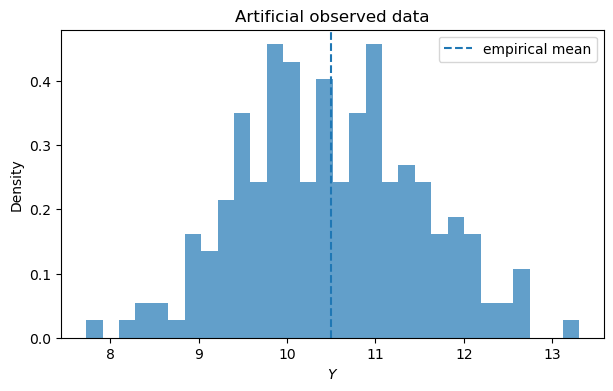

In [5]:
plt.figure(figsize=(7, 4))
plt.hist(y_obs, bins=30, density=True, alpha=0.7)
plt.axvline(np.mean(y_obs), linestyle="--", label="empirical mean")
plt.xlabel(r"$Y$")
plt.ylabel("Density")
plt.title("Artificial observed data")
plt.legend()
plt.show()

<div style="color:yellow; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Comparison between theoretical and empirical means and variances of the distribution of Y
</div>
For one log-normal variable

$$
Z = \exp(X),
\qquad X\sim \mathcal N(\mu,\sigma^2),
$$

we have

$$
\mathbb E[Z]
=
\exp\left(\mu+\frac{\sigma^2}{2}\right),
$$

and

$$
\mathrm{Var}(Z)
=
\left(\exp(\sigma^2)-1\right)
\exp(2\mu+\sigma^2).
$$

Since

$$
Y = \sum_{\ell=1}^{L} Z_\ell
$$

with independent $Z_\ell$, we get

$$
\mathbb E[Y]
=
L \exp\left(\mu+\frac{\sigma^2}{2}\right),
$$

and

$$
\mathrm{Var}(Y)
=
L\left(\exp(\sigma^2)-1\right)
\exp(2\mu+\sigma^2).
$$


In [6]:
def theoretical_moments_sum_lognormal(L, mu, sigma):
    sigma2 = sigma**2
    
    mean_Z = np.exp(mu + sigma2 / 2)
    var_Z = (np.exp(sigma2) - 1) * np.exp(2 * mu + sigma2)
    
    mean_Y = L * mean_Z
    var_Y = L * var_Z
    
    return mean_Y, var_Y
mean_theoretical, var_theoretical = theoretical_moments_sum_lognormal(L,mu_true,sigma_true)

mean_empirical = np.mean(y_obs)
var_empirical = np.var(y_obs, ddof=1)

moment_check = pd.DataFrame({
    "quantity": ["mean", "variance"],
    "theoretical": [mean_theoretical, var_theoretical],
    "empirical": [mean_empirical, var_empirical]
})

moment_check

,quantity,theoretical,empirical
0,mean,10.460279,10.499273
1,variance,1.030431,1.022738


The summary table and the histogram give a first check of the simulated observed data.

The empirical mean is around 10.45, and the empirical variance is around 1.10 ,which is consistent with the theoretical values. Indeed:

$$
\mathbb E[Y]
=
L \exp\left(\mu+\frac{\sigma^2}{2}\right),
$$

and

$$
\mathrm{Var}(Y)
=
L\left(\exp(\sigma^2)-1\right)
\exp(2\mu+\sigma^2).
$$

With

$$
\mu_0=0,
\qquad
\sigma_0=0.3,
\qquad
\sigma_0^2=0.09,
$$

we get

$$
\mathbb E[\exp(X_{i,\ell})]
=
\exp(0.045)
\approx 1.046.
$$

Since \(L=10\),

$$
\mathbb E[Y_i]
=
10\times 1.046
\approx 10.46.
$$

$$
\mathrm{Var}(Y_i)
=
10\left(\exp(0.09)-1\right)\exp(0.09)
\approx 1.03.
$$ 

The minimum and maximum values are also reasonable. Since each term $\\exp(X_{i,\ell})$ is positive, all observations $Y_i$ are positive. Most values are concentrated around 10, as shown by the quartiles and by the histogram. The histogram also shows a slight right skew, which is expected because the exponential transformation can produce larger positive values.

This confirms that the simulator is working correctly.

The next step is to use this simulated dataset as our "observed" data and apply Reject-ABC to estimate

$$
\theta = (\mu,\sigma^2).
$$

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Distance between observed and simulated datasets
</div>
Reject-ABC requires a distance to compare the observed dataset $y_{1:n}$ and a simulated dataset $z_{1:n}$.

Following Bernton et al. (2019), we use a Wasserstein distance, which is based on the theory of Optimal Transport.

<div style="color:yellow; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Intuition
</div>

The Wasserstein distance can be understood as a transportation cost.

Imagine that the observed sample $y_{1:n}$ is one pile of mass, and the simulated sample $z_{1:n}$ is another pile of mass. The Wasserstein distance measures the minimum cost required to move the mass of the first empirical distribution so that it matches the second one.

Thus, the distance is small when the observed and simulated samples have similar values and a similar distribution, and large when the simulated sample looks very different from the observed one.

<div style="color:yellow; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
General definition
</div>

Let $\mu$ and $\nu$ be two probability distributions.

The $p$-Wasserstein distance is defined by

$$
W_p(\mu,\nu)^p
=
\inf_{\gamma\in\Gamma(\mu,\nu)}
\int_{\mathcal Y\times\mathcal Y}
|x-y|^p\,d\gamma(x,y).
$$

Here, $\Gamma(\mu,\nu)$ is the set of all probability measures on $\mathcal Y\times\mathcal Y$ whose marginals are $\mu$ and $\nu$.
$\Gamma$ can be understood as a joint distribution of two random variables (X,Y), where 
$$
X \sim \mu,
\qquad
Y \sim \nu.
$$

The set $\Gamma(\mu,\nu)$ is the set of all possible joint distributions $\Gamma$ whose marginals are $\mu$ and $\nu$.
Thus,

$$
\int |x-y|^p\,d\gamma(x,y)
$$

can be read as

$$
\mathbb E_\gamma\left[|X-Y|^p\right].
$$

The Wasserstein distance chooses, among all joint distributions with marginals $\mu$ and $\nu$., the one that minimizes this expected cost:

$$
W_p(\mu,\nu)^p
=
\inf_{\gamma\in\Gamma(\mu,\nu)}
\mathbb E_\gamma\left[|X-Y|^p\right].
$$

In optimal transport terminology, such a joint distribution \(\gamma\) is called a transport plan. It tells us how much mass is transported from a point $x$ in the first distribution to a point $y$ in the second distribution.

The integral

$$
\int_{\mathcal Y\times\mathcal Y}
|x-y|^p\,d\gamma(x,y)
$$

is the average transportation cost under the transport plan $\gamma$.

The infimum means that we choose the transport plan with the smallest possible cost.

<div style="color:yellow; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Empirical distributions
</div>

In the algorithm, we do not compare two abstract distributions directly. We compare two finite samples:

$$
y_{1:n}=(y_1,\dots,y_n),
\qquad
z_{1:n}=(z_1,\dots,z_n).
$$

These samples define empirical distributions:

$$
\widehat{\mu}_y
=
\frac{1}{n}\sum_{i=1}^{n}\delta_{y_i},
\qquad
\widehat{\mu}_z
=
\frac{1}{n}\sum_{j=1}^{n}\delta_{z_j}.
$$

This means that each observation carries mass $1/n$.

Since these empirical distributions are discrete, the integral in the general definition becomes a finite sum. The empirical transport problem becomes

$$
W_p(y_{1:n},z_{1:n})^p
=
\inf_{\gamma\in\Gamma_n}
\sum_{i=1}^{n}
\sum_{j=1}^{n}
|y_i-z_j|^p\gamma_{ij},
$$

where $\gamma_{ij}$ is the amount of mass transported from $y_i$ to $z_j$.

The set $\Gamma_n$ contains all matrices $\gamma=(\gamma_{ij})$ with non-negative entries such that

$$
\sum_{j=1}^{n}\gamma_{ij}
=
\frac{1}{n},
\qquad
\sum_{i=1}^{n}\gamma_{ij}
=
\frac{1}{n}.
$$

The first constraint means that each observed point $y_i$ sends total mass $1/n$.

The second constraint means that each simulated point $z_j$ receives total mass $1/n$.

<div style="color:yellow; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Simplification in dimension one
</div>

Our data are one-dimensional. In dimension one, the optimal transport plan is obtained by sorting both samples and matching observations with the same rank.

Let

$$
y_{(1)}\leq y_{(2)}\leq \cdots \leq y_{(n)}
$$

and

$$
z_{(1)}\leq z_{(2)}\leq \cdots \leq z_{(n)}
$$

be the sorted observed and simulated samples.

Then the optimal matching is

$$
y_{(1)} \leftrightarrow z_{(1)},
\qquad
y_{(2)} \leftrightarrow z_{(2)},
\qquad
\dots,
\qquad
y_{(n)} \leftrightarrow z_{(n)}.
$$

Therefore,

$$
W_p(y_{1:n},z_{1:n})^p
=
\frac{1}{n}
\sum_{i=1}^{n}
|y_{(i)}-z_{(i)}|^p.
$$

In this project, we use $p=1$. Thus,

$$
W_1(y_{1:n},z_{1:n})
=
\frac{1}{n}
\sum_{i=1}^{n}
|y_{(i)}-z_{(i)}|.
$$

This is the distance used in our Reject-ABC algorithm:

$$
d(y_{1:n},z_{1:n})
=
W_1(y_{1:n},z_{1:n}).
$$

And a proposed parameter is accepted if

$$
W_1(y_{1:n},z_{1:n})\leq \varepsilon.
$$

In [7]:
def wasserstein_1d(y, z):
    y_sorted = np.sort(y)
    z_sorted = np.sort(z)
    return np.mean(np.abs(y_sorted - z_sorted))

We now define a function that samples N independent parameter values from the prior. For each $j=1,\dots,N$, it draws

$$
\mu^{(j)}\sim \mathcal N(0,s^2),
\qquad
\eta^{(j)}=\log(\sigma^{2(j)})\sim \mathcal N(0,t^2),
$$

then returns 

$$
\mu^{(j)},
\qquad
\sigma^{2(j)}=\exp(\eta^{(j)}),
\qquad
\sigma^{(j)}=\sqrt{\sigma^{2(j)}}.
$$

In [8]:
def sample_prior(N, s, t, rng):
    mu_samples = rng.normal(loc=0.0, scale=s, size=N)
    
    eta_samples = rng.normal(loc=0.0, scale=t, size=N)
    sigma2_samples = np.exp(eta_samples)
    sigma_samples = np.sqrt(sigma2_samples)
    
    return mu_samples, sigma2_samples, sigma_samples

We now implement the Reject-ABC algorithm described above.  
For each prior draw $\theta^{(j)}$=($\mu^{(j)}$,$\sigma^{2(j)}$) with $j \in 1,\dots,N$, the function simulates a synthetic dataset $z_{1:n}^{(j)} \sim p(\cdot \mid \theta^{(j)})$, computes its Wasserstein distance to the observed dataset, and accepts the parameter if this distance is smaller than the chosen tolerance $\varepsilon$.

Because the scale of the Wasserstein distances is not known in advance, it is not easy to fix a value of $\varepsilon$ directly. Instead, we can choose an acceptance quantile q. 

After computing all distances

$$
d_1,\dots,d_N,
$$

we set

$$
\varepsilon = Q_q(d_1,\dots,d_N),
$$

where $Q_q$ is the empirical q-quantile of the distances.

This means that we accept the best q proportion of simulations.

For example, if

$$
N=20000
\qquad \text{and} \qquad
q=0.01,
$$

then we accept 200 parameter values.

This approach makes it easier to compare different experiments because the acceptance rate is controlled directly.
So, if $\varepsilon$ is not fixed directly, we choose it as the empirical q-quantile of all simulated distances, so that approximately the best q proportion of simulations is accepted.


In [10]:
def reject_abc(y_obs, L, N, s, t, epsilon=None, q=None, rng=None):

    if epsilon is None and q is None:
        raise ValueError("You must provide either epsilon or q.")
    
    n = len(y_obs)
    
    # Draw parameters from the prior
    mu_samples, sigma2_samples, sigma_samples = sample_prior(N,s,t,rng)

    # Simulate data and compute distances
    distances = np.empty(N)
    for j in range(N):
        z_sim = simulate_sum_lognormal(n,L,mu_samples[j],sigma_samples[j],rng)
        distances[j] = wasserstein_1d(y_obs, z_sim)
    
    # Choose epsilon either directly or as a quantile of the distances
    if epsilon is None:
        epsilon_used = np.quantile(distances, q)
    else:
        epsilon_used = epsilon
    
    accepted = distances <= epsilon_used
    
    all_results = pd.DataFrame({
        "mu": mu_samples,
        "sigma2": sigma2_samples,
        "sigma": sigma_samples,
        "distance": distances,
        "accepted": accepted
    })
    
    accepted_results = all_results[all_results["accepted"]].copy()
    
    return all_results, accepted_results, epsilon_used

In [ ]:
# ABC settings
N = 20_000
s = 1.0
t = 2.0

# Keep the best 1% of simulations
q = 0.01

all_results, abc_samples, epsilon_used = reject_abc(y_obs,L,N,s,t,q,rng)

print(f"epsilon used: {epsilon_used:.4f}")
print(f"number accepted: {len(abc_samples)}")
print(f"acceptance rate: {len(abc_samples) / N:.4f}")

epsilon used: 0.5955
number accepted: 200
acceptance rate: 0.0100


<div style="color:yellow; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Descriptive statistics on the ditributions of the accepted set of mu and sigma
</div>

In [21]:
abc_summary = abc_samples[["mu","sigma2","sigma"]].describe()
abc_summary

,mu,sigma2,sigma
count,200.000000,200.000000,200.000000
mean,-0.006184,0.109738,0.313432
std,0.044882,0.069013,0.107501
min,-0.124612,0.009465,0.097286
25%,-0.034786,0.050478,0.224664
50%,-0.004562,0.099618,0.315622
75%,0.024500,0.165038,0.406249
max,0.083398,0.328171,0.572862


<div style="color:yellow; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Histograms of mu and sigma^2
</div>

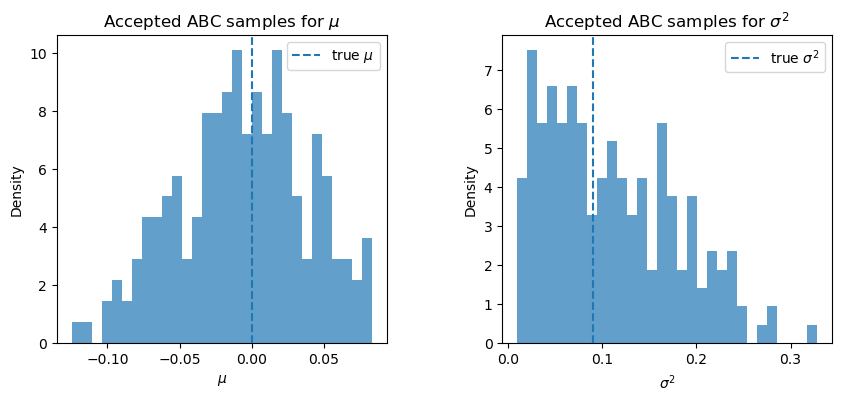

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Histogram of mu
axes[0].hist(abc_samples["mu"], bins=30, density=True, alpha=0.7)
axes[0].axvline(mu_true, linestyle="--", label=r"true $\mu$")
axes[0].set_title(r"Accepted ABC samples for $\mu$")
axes[0].set_xlabel(r"$\mu$")
axes[0].set_ylabel("Density")
axes[0].legend()

# Histogram of sigma2
axes[1].hist(abc_samples["sigma2"], bins=30, density=True, alpha=0.7)
axes[1].axvline(sigma2_true, linestyle="--", label=r"true $\sigma^2$")
axes[1].set_title(r"Accepted ABC samples for $\sigma^2$")
axes[1].set_xlabel(r"$\sigma^2$")
axes[1].set_ylabel("Density")
axes[1].legend()

fig.subplots_adjust(wspace=0.35)  

plt.show()

For $\mu$, the accepted values are centered close to the true value. The empirical mean is approximately $\overline{\mu}_{ABC}\approx -0.006$, and the median is approximately $\mathrm{med}(\mu)\approx -0.005$.

Both are very close to 0. The histogram of $\mu$ is concentrated around the true value, which suggests that Reject-ABC recovers the location parameter well in this first experiment.

For $\sigma^2$, the accepted values are more spread out. The mean is approximately $\overline{\sigma^2}_{ABC}\approx 0.110$, while the median is approximately $\mathrm{med}(\sigma^2)\approx 0.100$.

These values are close to the true value $\sigma_0^2=0.09$.

The histogram of $\sigma^2$ is slightly right-skewed: most accepted values are near the true value, but some larger values of $\sigma^2$ are also accepted. This explains why the mean is a bit larger than the median.

Overall, this first Reject-ABC run gives reasonable estimates of both components of $\theta=(\mu,\sigma^2)$.

In this experiment, $\sigma^2$ appears to be estimated with more uncertainty than $\mu$.

<div style="color:yellow; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Cloud of (mu, sigma^2)
</div>

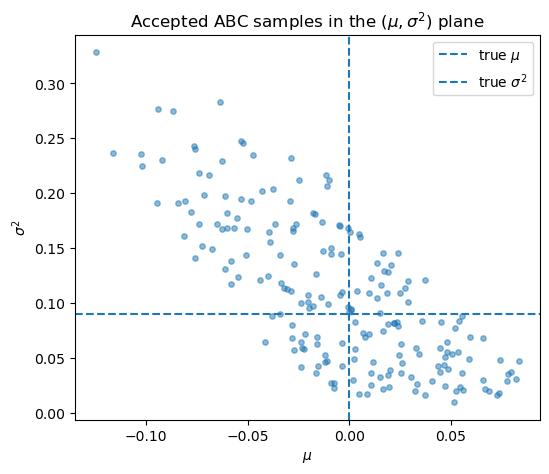

In [29]:
plt.figure(figsize=(6, 5))
plt.scatter(
    abc_samples["mu"],
    abc_samples["sigma2"],
    alpha=0.5,
    s=15
)
plt.axvline(mu_true, linestyle="--", label=r"true $\mu$")
plt.axhline(sigma2_true, linestyle="--", label=r"true $\sigma^2$")
plt.xlabel(r"$\mu$")
plt.ylabel(r"$\sigma^2$")
plt.title(r"Accepted ABC samples in the $(\mu,\sigma^2)$ plane")
plt.legend()
plt.show()

The scatter plot shows the accepted ABC samples in the $(\mu,\sigma^2)$ plane. Each point corresponds to one accepted parameter value.

The dashed vertical and horizontal lines represent the true values 
$$
\mu_0=0,
\qquad
\sigma_0^2=0.09.
$$

The accepted points are concentrated around the true region, which confirms that Reject-ABC is selecting parameter values that are compatible with the observed data.

The plot also shows a negative dependence between $\mu$ and $\sigma^2$: when $\mu$ is smaller, accepted values of $\sigma^2$ tend to be larger, and when $\mu$ is larger, accepted values of $\sigma^2$ tend to be smaller.

This can be understood from the expectation of a log-normal variable:

$$
\mathbb E[\exp(X)]
=
\exp\left(\mu+\frac{\sigma^2}{2}\right).
$$

Therefore,

$$
\mathbb E[Y_i]
=
L\exp\left(\mu+\frac{\sigma^2}{2}\right).
$$

The accepted values are chosen because their simulated datasets are close to the observed dataset according to the Wasserstein distance. If the simulated values were much smaller or much larger, the Wasserstein distance would be large and the parameter would be rejected. So, accepted parameters tend to produce a similar typical size for $Y_i$. Here, by “typical size” we mean the general scale of the simulated observations, for example their mean. Since the observed $Y_i$'s are mostly around 10, accepted simulations must also produce $Y_i$'s on a similar scale. 

Both $\mu$ and $\sigma^2$ influence the typical size of $Y_i$ which we consider is $\mathbb E[Y_i]=L\exp\left(\mu+\frac{\sigma^2}{2}\right)$. If $\mu$ is slightly smaller, a larger value of $\sigma^2$ can partly compensate for it, because the term $\mu+\frac{\sigma^2}{2}$ should remain similar. Conversely, if $\mu$ is slightly larger, a smaller value of $\sigma^2$ can still produce simulated datasets close to the observed one. 

<div style="color:yellow; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Observation vs simulation
</div>

In [16]:
mu_abc_median = abc_samples["mu"].median()
sigma_abc_median = abc_samples["sigma"].median()
sigma2_abc_median = sigma_abc_median**2

print("ABC median estimate:")
print(f"mu     = {mu_abc_median:.4f}")
print(f"sigma  = {sigma_abc_median:.4f}")
print(f"sigma2 = {sigma2_abc_median:.4f}")

ABC median estimate:
mu     = -0.0046
sigma  = 0.3156
sigma2 = 0.0996


To visually check the quality of the Reject-ABC result, we compare two datasets.

The first dataset is the artificial observed dataset

$$
y_{1:n},
$$

which was generated at the beginning of the project using the true parameters

$$
\mu_0=0,
\qquad
\sigma_0=0.3,
\qquad
\sigma_0^2=0.09.
$$

The second dataset is a new simulated dataset

$$
z_{1:n}^{ABC},
$$

generated from the same model, but using the median of the accepted ABC parameters:

$$
\widehat{\mu}_{ABC}\approx -0.005,
\qquad
\widehat{\sigma}_{ABC}\approx 0.316,
\qquad
\widehat{\sigma^2}_{ABC}\approx 0.100.
$$

Thus, we are comparing data generated from the true parameter values with data generated from the parameter values estimated by Reject-ABC.

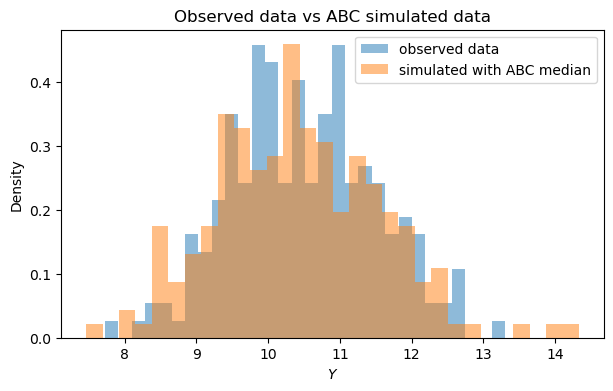

In [34]:
sigma2_abc_median = abc_samples["sigma2"].median()

z_abc = simulate_sum_lognormal(n,L,mu_abc_median,np.sqrt(sigma2_abc_median),rng)

plt.figure(figsize=(7, 4))
plt.hist(y_obs, bins=30, density=True, alpha=0.5, label="observed data")
plt.hist(z_abc, bins=30, density=True, alpha=0.5, label="simulated with ABC median")
plt.xlabel(r"$Y$")
plt.ylabel("Density")
plt.title("Observed data vs ABC simulated data")
plt.legend()
plt.show()

The two histograms are close: both datasets are concentrated around the same range of values, roughly between 9 and 12, and they have a similar overall shape. This means that the ABC median estimate produces simulated data that resemble the observed data.

This visual comparison is consistent with the Reject-ABC procedure: the algorithm selects parameters that generate synthetic datasets close to the observed dataset according to the Wasserstein distance. Overall, this suggests that Reject-ABC has found plausible parameter values for the model.

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
## Impact of the tolerance parameter epsilon
</div>

The tolerance parameter $\varepsilon$ controls how strict the ABC acceptance rule is.

A proposed parameter $\theta^{(j)}$ is accepted if

$$
W_1(y_{1:n}, z_{1:n}^{(j)}) \leq \varepsilon.
$$

If $\varepsilon$ is large, many simulated datasets are accepted. This gives more accepted parameters, but some of them may generate data that are not very close to the observed dataset.

If $\varepsilon$ is small, only very close simulations are accepted. This gives a better ABC approximation, but the acceptance rate becomes smaller.

In practice, instead of fixing $\varepsilon$ directly, we choose an acceptance quantile $q$. After computing the distances

$$
d_1,\dots,d_N,
$$

we set

$$
\varepsilon = Q_q(d_1,\dots,d_N),
$$

where $Q_q$ is the empirical $q$-quantile of the distances.

Thus, choosing a smaller $q$ is equivalent to choosing a smaller tolerance $\varepsilon$.

In [35]:
def summarize_epsilon_effect(all_results, quantiles):
    rows = []

    for q_val in quantiles:
        eps = np.quantile(all_results["distance"], q_val)
        acc = all_results[all_results["distance"] <= eps]

        rows.append({
            "q": q_val,
            "epsilon": eps,
            "n_accepted": len(acc),
            "acceptance_rate": len(acc) / len(all_results),
            "mu_median": acc["mu"].median(),
            "mu_mean": acc["mu"].mean(),
            "mu_sd": acc["mu"].std(),
            "sigma2_median": acc["sigma2"].median(),
            "sigma2_mean": acc["sigma2"].mean(),
            "sigma2_sd": acc["sigma2"].std(),
            "sigma_median": acc["sigma"].median(),
            "mean_distance_accepted": acc["distance"].mean()
        })

    return pd.DataFrame(rows)

In [43]:
quantiles = [0.001,0.005, 0.01, 0.02, 0.05]

epsilon_summary = summarize_epsilon_effect(all_results, quantiles)
epsilon_summary.round(4)

,q,epsilon,n_accepted,acceptance_rate,mu_median,mu_mean,mu_sd,sigma2_median,sigma2_mean,sigma2_sd,sigma_median,mean_distance_accepted
0,0.001,0.1735,20,0.001,0.0019,0.0017,0.0157,0.0924,0.0926,0.0168,0.3040,0.1256
1,0.005,0.3871,100,0.005,0.0026,0.0009,0.0305,0.0924,0.0970,0.0457,0.3040,0.2653
2,0.010,0.5955,200,0.010,-0.0046,-0.0062,0.0449,0.0996,0.1097,0.0690,0.3156,0.3820
3,0.020,0.9112,400,0.020,-0.0226,-0.0230,0.0657,0.1169,0.1350,0.0982,0.3419,0.5707
4,0.050,1.6969,1000,0.050,-0.0724,-0.0748,0.1254,0.1784,0.2219,0.1774,0.4224,1.0326


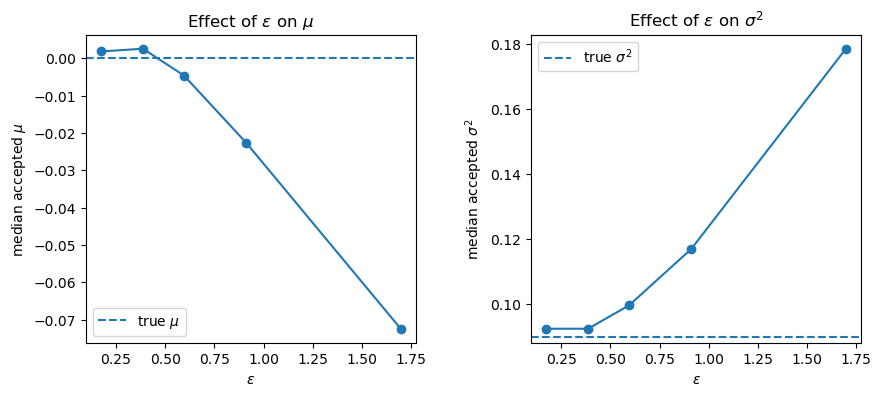

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Effect of epsilon on mu
axes[0].plot(epsilon_summary["epsilon"], epsilon_summary["mu_median"], marker="o")
axes[0].axhline(mu_true, linestyle="--", label=r"true $\mu$")
axes[0].set_xlabel(r"$\varepsilon$")
axes[0].set_ylabel(r"median accepted $\mu$")
axes[0].set_title(r"Effect of $\varepsilon$ on $\mu$")
axes[0].legend()

# Effect of epsilon on sigma2
axes[1].plot(epsilon_summary["epsilon"], epsilon_summary["sigma2_median"], marker="o")
axes[1].axhline(sigma2_true, linestyle="--", label=r"true $\sigma^2$")
axes[1].set_xlabel(r"$\varepsilon$")
axes[1].set_ylabel(r"median accepted $\sigma^2$")
axes[1].set_title(r"Effect of $\varepsilon$ on $\sigma^2$")
axes[1].legend()

fig.subplots_adjust(wspace=0.35)
plt.show()

The table and the plots show how the Reject-ABC result changes when the tolerance $\varepsilon$ increases.

Here, $\varepsilon$ is chosen through an acceptance quantile $q$. When $q$ increases, we keep a larger proportion of simulations, so the selected tolerance $\varepsilon$ also increases. For example, with

$$
q=0.001,
$$

only \(20\) simulations are accepted, whereas with

$$
q=0.05,
$$

\(1000\) simulations are accepted.

For small values of $\varepsilon$, the accepted parameter summaries are close to the true values

$$
\mu_0=0,
\qquad
\sigma_0^2=0.09.
$$

This is expected because a small tolerance only accepts simulated datasets that are very close to the observed dataset.

When $\varepsilon$ becomes larger, the acceptance rule becomes less strict. The algorithm accepts simulated datasets that are less close to the observed data. In this experiment, this makes the median accepted value of $\mu$ decrease from \(0\), while the median accepted value of $\sigma^2$ increases above the true value \(0.09\).

Thus, $\varepsilon$ controls a trade-off. A small $\varepsilon$ gives a stricter and potentially more accurate ABC approximation, but it also gives fewer accepted samples. With too few accepted samples, posterior summaries such as medians, quantiles, and histograms may be unstable and less reliable because they are based on few points.

On the other hand, a large $\varepsilon$ gives more accepted samples, but the ABC approximation becomes rougher and can introduce more bias.

In this experiment, using

$$
q=0.01
$$

gives

$$
\varepsilon \approx 0.60
$$

and \(200\) accepted samples. This appears to be a reasonable compromise: the accepted parameters remain close to the true values, while the number of accepted samples is large enough to summarize the ABC posterior.

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Impact of the prior parameters s and t
</div>

The prior used in Reject-ABC is

$$
\mu \sim \mathcal N(0,s^2),
\qquad
\log(\sigma^2)\sim \mathcal N(0,t^2).
$$

The parameter s controls how widely the prior explores possible values of $\mu$.

If s is too small, the prior

$$
\mu \sim \mathcal N(0,s^2)
$$

is very concentrated around 0. In our simulated example, this is not necessarily a problem because the true value is

$$
\mu_0=0.
$$

However, in a real inference problem, the true value of $\mu$ is unknown. If the true value were not close to 0, a very small s could prevent the algorithm from proposing good values of $\mu$.

On the other hand, if s is too large, the prior becomes very diffuse. It includes the true region, but it also proposes many values of $\mu$ that are far from the data-generating region. This can make Reject-ABC less efficient, because many simulations are wasted on unrealistic parameter values.

The parameter t controls how widely the prior explores possible values of $\log(\sigma^2)$.

In our simulated experiment, the true variance is

$$
\sigma_0^2 = 0.09,
$$

so

$$
\log(\sigma_0^2)=\log(0.09)\approx -2.41.
$$

Therefore, if \(t\) is too small, the prior

$$
\log(\sigma^2)\sim \mathcal N(0,t^2)
$$

puts very little probability mass near -2.41. In that case, Reject-ABC may rarely propose values of $\sigma^2$ close to the true value.

If t is too large, the prior includes the true region, but it also proposes many unrealistic values of $\sigma^2$. This can also reduce the efficiency of the algorithm.

Thus, both s and t create the same general trade-off:

$$
\text{prior too concentrated}
\quad \Longrightarrow \quad
\text{risk of missing the true parameter region},
$$

whereas

$$
\text{prior too diffuse}
\quad \Longrightarrow \quad
\text{many simulations wasted in irrelevant regions}.
$$

In this particular simulated experiment, the effect of t is especially important because the true value $\log(\sigma_0^2)\approx -2.41$ is far from the prior center 0 when t is small.

In [ ]:
def run_prior_sensitivity(y_obs, L, N_grid, s_values, t_values):
    rows = []
    k = 0

    for s_val in s_values:
        for t_val in t_values:
            all_res, acc_res, eps = reject_abc(y_obs,L,N_grid,s_val,t_val,q,rng)

            rows.append({
                "s": s_val,
                "t": t_val,
                "epsilon": eps,
                "n_accepted": len(acc_res),
                "acceptance_rate": len(acc_res) / N_grid,
                "mu_median": acc_res["mu"].median(),
                "mu_mean": acc_res["mu"].mean(),
                "mu_sd": acc_res["mu"].std(),
                "sigma2_median": acc_res["sigma2"].median(),
                "sigma2_mean": acc_res["sigma2"].mean(),
                "sigma2_sd": acc_res["sigma2"].std(),
                "sigma_median": acc_res["sigma"].median()
            })

            k += 1

    summary = pd.DataFrame(rows)

    summary["mu_abs_error"] = np.abs(summary["mu_median"] - mu_true)
    summary["sigma2_abs_error"] = np.abs(summary["sigma2_median"] - sigma2_true)
    summary["total_abs_error"] = summary["mu_abs_error"] + summary["sigma2_abs_error"]

    return summary

In [ ]:
s_values = [0.5, 1.0, 2.0]
t_values = [0.5, 1.0, 2.0, 3.0]

N_grid = 10_000
q_grid = 0.01

prior_summary = run_prior_sensitivity(y_obs,L,N_grid,s_values,t_values,q_grid)

/var/folders/45/48t8s0w969gbt8ry74nlqvcw0000gn/T/ipykernel_97526/1809667945.py:4: RuntimeWarning: overflow encountered in exp
  Y = np.exp(X).sum(axis=1)
/var/folders/45/48t8s0w969gbt8ry74nlqvcw0000gn/T/ipykernel_97526/1809667945.py:4: RuntimeWarning: overflow encountered in exp
  Y = np.exp(X).sum(axis=1)
/var/folders/45/48t8s0w969gbt8ry74nlqvcw0000gn/T/ipykernel_97526/1809667945.py:4: RuntimeWarning: overflow encountered in exp
  Y = np.exp(X).sum(axis=1)


,s,t,epsilon,n_accepted,acceptance_rate,mu_median,mu_mean,mu_sd,sigma2_median,sigma2_mean,sigma2_sd,sigma_median,mu_abs_error,sigma2_abs_error,total_abs_error
0,0.5,0.5,1.2738,100,0.01,-0.1633,-0.1548,0.0622,0.4088,0.4027,0.0706,0.6394,0.1633,0.3188,0.4821
1,0.5,1.0,0.7269,100,0.01,-0.0549,-0.0508,0.0506,0.1963,0.1913,0.0610,0.4431,0.0549,0.1063,0.1612
2,0.5,2.0,0.4568,100,0.01,0.0002,-0.0033,0.0350,0.1101,0.1125,0.0541,0.3318,0.0002,0.0201,0.0203
3,0.5,3.0,0.4123,100,0.01,0.0090,0.0034,0.0314,0.0724,0.0896,0.0501,0.2691,0.0090,0.0176,0.0265
4,1.0,0.5,1.5059,100,0.01,-0.2077,-0.1934,0.0835,0.4579,0.4528,0.1081,0.6767,0.2077,0.3679,0.5757
5,1.0,1.0,0.9838,100,0.01,-0.0696,-0.0661,0.0662,0.2228,0.2340,0.0917,0.4721,0.0696,0.1328,0.2025
6,1.0,2.0,0.6325,100,0.01,-0.0048,-0.0083,0.0461,0.1111,0.1119,0.0671,0.3334,0.0048,0.0211,0.0259
7,1.0,3.0,0.5987,100,0.01,0.0082,0.0034,0.0456,0.0730,0.0911,0.0652,0.2702,0.0082,0.0170,0.0252
8,2.0,0.5,1.5802,100,0.01,-0.2235,-0.2062,0.0817,0.4747,0.4751,0.1230,0.6890,0.2235,0.3847,0.6083
9,2.0,1.0,1.2989,100,0.01,-0.1083,-0.1048,0.0893,0.2991,0.2963,0.1218,0.5469,0.1083,0.2091,0.3174


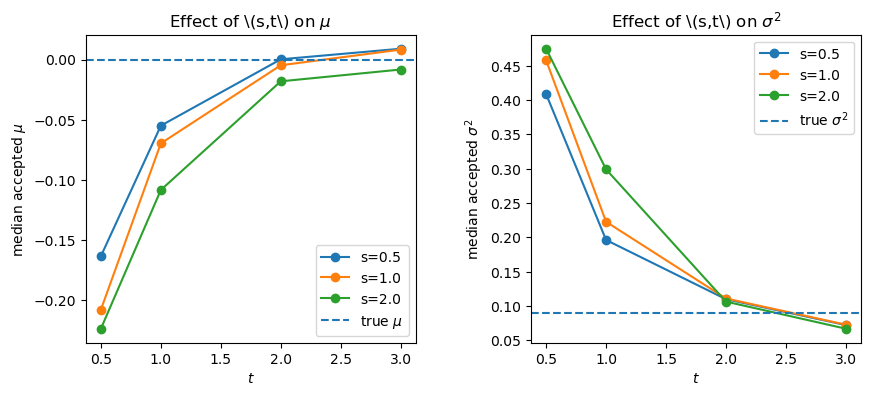

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for s_val in s_values:
    sub = prior_summary[prior_summary["s"] == s_val].sort_values("t")

    axes[0].plot(sub["t"],sub["mu_median"],marker="o",label=f"s={s_val}")

    axes[1].plot(sub["t"],sub["sigma2_median"],marker="o",label=f"s={s_val}")

axes[0].axhline(mu_true, linestyle="--", label=r"true $\mu$")
axes[0].set_xlabel(r"$t$")
axes[0].set_ylabel(r"median accepted $\mu$")
axes[0].set_title(r"Effect of (s,t) on $\mu$")
axes[0].legend()

axes[1].axhline(sigma2_true, linestyle="--", label=r"true $\sigma^2$")
axes[1].set_xlabel(r"$t$")
axes[1].set_ylabel(r"median accepted $\sigma^2$")
axes[1].set_title(r"Effect of (s,t) on $\sigma^2$")
axes[1].legend()

fig.subplots_adjust(wspace=0.35)
plt.show()

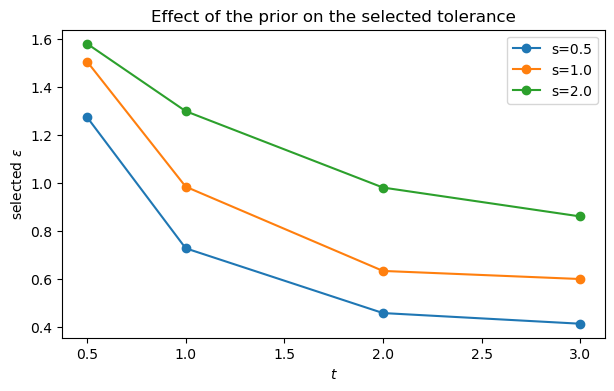

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

for s_val in s_values:
    sub = prior_summary[prior_summary["s"] == s_val].sort_values("t")

    ax.plot(sub["t"],sub["epsilon"],marker="o",label=f"s={s_val}")

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"selected $\varepsilon$")
ax.set_title(r"Effect of the prior on the selected tolerance")
ax.legend()
plt.show()

The plots show the impact of the prior parameters $s$ and $t$ on the Reject-ABC result.

In this experiment, the effect of $t$ is especially important. When $t$ is small, the prior

$$
\log(\sigma^2)\sim \mathcal N(0,t^2)
$$

is concentrated near $0$. This means that $\sigma^2$ is mostly proposed near $\exp(0)=1$, which is far from the true value $\sigma_0^2=0.09$.

As a consequence, for small values of $t$, the accepted values of $\sigma^2$ are too large, and the accepted values of $\mu$ tend to be negative. This negative shift in $\mu$ partly compensates for the too large values of $\sigma^2$.

When $t$ increases, the prior on $\log(\sigma^2)$ becomes more diffuse and starts to put more mass near the true value

$$
\log(\sigma_0^2)=\log(0.09)\approx -2.41.
$$

Therefore, the algorithm is more likely to propose values of $\sigma^2$ close to the true parameter. This is visible in the plots: as $t$ increases, the accepted median of $\sigma^2$ moves closer to $0.09$, and the accepted median of $\mu$ moves closer to $0$.

The parameter $s$ also matters, because it controls how widely the algorithm explores possible values of $\mu$. In this simulated example, the true value is $\mu_0=0$, so a prior centered at $0$ with a moderate spread already works reasonably well. However, if $s$ is too large, the algorithm proposes many values of $\mu$ that are far from the region supported by the data, which can reduce efficiency.

The plot of the selected tolerance $\varepsilon$ also reflects this. Since the acceptance quantile $q$ is fixed, a smaller selected $\varepsilon$ means that the best accepted simulations are closer to the observed data. We observe that larger values of $t$ generally lead to smaller selected tolerances, meaning that the prior explores the true region better.

Overall, these experiments show that the prior must be wide enough to include the true parameter region, but not so wide that most simulations are wasted on unrealistic values. In this example, choosing $t$ too small is particularly problematic because the true value of $\log(\sigma^2)$ is far from the prior center $0$.

<div style="color:#FF4D4D; font-size:2em; font-weight:700; margin-bottom:0.4em;">
MCMC-ABC
</div>

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Objective
</div>

In Part 1, we used Reject-ABC to approximate the ABC posterior distribution

$$
\pi_\varepsilon(\theta \mid y_{1:n}).
$$

The goal is now to construct an MCMC sampler that targets the same ABC posterior distribution, but explores the parameter space through local moves instead of drawing each parameter independently from the prior.

This construction is directly inspired by Marjoram et al. (2003). In their article, the authors introduce a general “MCMC without likelihoods” scheme: from the current parameter value, one proposes a new parameter $\theta'$ from a transition kernel $q(\theta \to \theta')$, simulates a synthetic dataset under $\theta'$, and accepts the proposal only if the simulated data are sufficiently close to the observed data. In our project, we adapt this general framework to the sum-of-log-normal model.

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
ABC target
</div>

Let $y_{1:n}$ denote the observed dataset. For a parameter $\theta$, we simulate a synthetic dataset

$$
z_{1:n} \sim p(\cdot \mid \theta).
$$

The ABC target on the augmented space $(\theta,z_{1:n})$ is

$$
\pi_\varepsilon(\theta,z_{1:n}\mid y_{1:n})
\propto
\pi(\theta)\,p(z_{1:n}\mid\theta)\,
\mathbf 1\!\left\{W_1(y_{1:n},z_{1:n})\leq \varepsilon\right\}.
$$

The marginal distribution of $\theta$ under this augmented target is the same ABC posterior distribution as in Part 1:

$$
\pi_\varepsilon(\theta\mid y_{1:n}).
$$

Therefore, if we construct an MCMC sampler with invariant distribution
$$
\pi_\varepsilon(\theta,z_{1:n}\mid y_{1:n}),
$$
then, after marginalizing over $z_{1:n}$, the chain targets the same ABC posterior distribution
$$
\pi_\varepsilon(\theta\mid y_{1:n})
$$
as Reject-ABC.

We will come back to this point after explaining the acceptance mechanism, and clarify why the sampled values of $\theta$ can then be interpreted as draws from the same ABC posterior distribution.


<div style="color:#4EA3FF; font-size:1.35em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Parameterization and proposal choice
</div>
Our prior is the same as in Part 1

$$
\mu \sim \mathcal N(0,s^2),
\qquad
\eta \sim \mathcal N(0,t^2).
$$

We use the parameterization

$$
\theta=(\mu,\eta).
$$

Marjoram et al. use a general proposal kernel $q(\theta \to \theta')$. In our implementation, we choose a Gaussian random-walk proposal:

$$
\mu'=\mu^{(k)}+\tau_\mu Z_\mu,
\qquad
\eta'=\eta^{(k)}+\tau_\eta Z_\eta,
\qquad
Z_\mu,Z_\eta\sim \mathcal N(0,1).
$$

We choose it because it is simple, standard, easy to implement, and symmetric. It is also well suited to our low-dimensional parameterization, since both $\mu$ and $\eta$ take values in $\mathbb R$.

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Acceptance rule
</div>

At iteration $k$, the current state is

$$
\theta^{(k)}=(\mu^{(k)},\eta^{(k)}).
$$

We first propose a new parameter $\theta'=(\mu',\eta')$ using the Gaussian random walk defined above, and then simulate

$$
z'_{1:n}\sim p(\cdot \mid \theta').
$$

We compute the Wasserstein distance

$$
d' = W_1(y_{1:n},z'_{1:n}).
$$

If

$$
d' > \varepsilon,
$$

the proposal is rejected immediately.

If

$$
d' \leq \varepsilon,
$$

we apply a Metropolis-Hastings correction. 

We want the Markov chain to target the joint ABC distribution

$$
\pi_\varepsilon(\theta,z_{1:n}\mid y_{1:n})
\propto
\pi(\theta)\,p(z_{1:n}\mid\theta)\,
\mathbf 1\left\{W_1(y_{1:n},z_{1:n})\leq \varepsilon\right\},
$$

Following the likelihood-free MCMC mechanism of Marjoram et al., we generate a proposed move in two steps:

- first propose $\theta'$ from $q(\theta' \mid \theta^{(k)})$,
- then simulate $z'_{1:n}$ from $p(\cdot \mid \theta')$.

Therefore, the proposal distribution of the full proposed state
$$
x'=(\theta',z'_{1:n})
$$
is

$$
g\big((\theta',z'_{1:n}) \mid (\theta,z_{1:n})\big)
=
q(\theta' \mid \theta)\,p(z'_{1:n}\mid \theta').
$$

Similarly, the reverse proposal density is

$$
g\big((\theta,z_{1:n}) \mid (\theta',z'_{1:n})\big)
=
q(\theta \mid \theta')\,p(z_{1:n}\mid \theta).
$$

To justify this, since the proposed move is generated sequentially, the proposal density on the augmented space is obtained by the chain rule for conditional densities:

$$
g\big((\theta',z'_{1:n}) \mid (\theta,z_{1:n})\big)
=
g_{1}\big(\theta' \mid \theta,z_{1:n}\big)\,
g_{2}\big(z'_{1:n} \mid \theta',\theta,z_{1:n}\big).
$$

with :

$$
g_1(\theta' \mid \theta,z_{1:n})
$$

denoting the conditional density of the proposed parameter $\theta'$ given the current state $(\theta,z_{1:n})$, and let

$$
g_2(z'_{1:n} \mid \theta',\theta,z_{1:n})
$$

denoting the conditional density of the proposed synthetic dataset $z'_{1:n}$ given $\theta'$, $\theta$, and $z_{1:n}$.


By construction of the algorithm,

$$
g_{1}\big(\theta' \mid \theta,z_{1:n}\big)=q(\theta' \mid \theta),
$$

because the proposed parameter depends only on the current parameter.

Moreover,

$$
g_{2}\big(z'_{1:n} \mid \theta',\theta,z_{1:n}\big)=p(z'_{1:n} \mid \theta'),
$$

because, once $\theta'$ is fixed, the synthetic dataset is simulated from the model under $\theta'$.

Therefore,

$$
g\big((\theta',z'_{1:n}) \mid (\theta,z_{1:n})\big)
=
q(\theta' \mid \theta)\,p(z'_{1:n} \mid \theta').
$$

Hence, the Metropolis-Hastings acceptance probability is

$$
\alpha
=
\min\left(
1,
\frac{
\pi_\varepsilon(\theta',z'_{1:n}\mid y_{1:n})\,
q(\theta^{(k)}\mid \theta')\,
p(z_{1:n}\mid \theta^{(k)})
}{
\pi_\varepsilon(\theta^{(k)},z_{1:n}\mid y_{1:n})\,
q(\theta'\mid \theta^{(k)})\,
p(z'_{1:n}\mid \theta')
}
\right).
$$

Substituting the expression of the ABC target gives

$$
\alpha
=
\min\left(
1,
\frac{
\pi(\theta')\,p(z'_{1:n}\mid\theta')\,
\mathbf 1\left\{W_1(y_{1:n},z'_{1:n})\leq \varepsilon\right\}
\,q(\theta^{(k)}\mid \theta')\,p(z_{1:n}\mid \theta^{(k)})
}{
\pi(\theta^{(k)})\,p(z_{1:n}\mid\theta^{(k)})\,
\mathbf 1\left\{W_1(y_{1:n},z_{1:n})\leq \varepsilon\right\}
\,q(\theta'\mid \theta^{(k)})\,p(z'_{1:n}\mid \theta')
}
\right).
$$

The terms

$$
p(z'_{1:n}\mid\theta')
\qquad\text{and}\qquad
p(z_{1:n}\mid\theta^{(k)})
$$

cancel.

And since we are in the case where $d' \leq \varepsilon$, then the indicator in the numerator is equal to $1$, and the acceptance probability becomes

$$
\alpha
=
\min\left(
1,
\frac{\pi(\theta')\,q(\theta^{(k)}\mid \theta')}
{\pi(\theta^{(k)})\,q(\theta'\mid \theta^{(k)})}
\right).
$$

Since our Gaussian random-walk proposal is symmetric, we have

$$
q(\theta^{(k)}\mid \theta')=q(\theta'\mid \theta^{(k)}),
$$

so the proposal terms cancel, and finally

$$
\alpha
=
\min\left(
1,
\frac{\pi(\theta')}{\pi(\theta^{(k)})}
\right).
$$

In practice, it is convenient to compute the acceptance step on the log-scale. Since the prior ratio appears in the Metropolis-Hastings probability, we can equivalently compare the log-prior values instead of the prior densities themselves, using the log-prior,

$$
\log \pi(\mu,\eta)
=
-\frac{1}{2}\frac{\mu^2}{s^2}
-\frac{1}{2}\frac{\eta^2}{t^2}
\quad
\text{(up to an additive constant),}
$$

If the proposal satisfies the ABC condition, we accept it with probability $\alpha$.

If
$$
\frac{\pi(\theta')}{\pi(\theta^{(k)})}\ge 1,
$$
then the proposal is accepted automatically.

Otherwise, if
$$
\frac{\pi(\theta')}{\pi(\theta^{(k)})}<1,
$$
this means that we draw

$$
R\sim \mathcal U(0,1)
$$

and accept the proposal if

$$
R\leq \alpha.
$$

this is equivalent to

$$
R\leq \frac{\pi(\theta')}{\pi(\theta^{(k)})}.
$$

Since the logarithm is an increasing function, this is in turn equivalent to

$$
\log R \leq \log \pi(\theta')-\log \pi(\theta^{(k)}).
$$

Thus, if the proposal is accepted, we set

$$
\theta^{(k+1)}=\theta',
$$

and otherwise we keep the current value:

$$
\theta^{(k+1)}=\theta^{(k)}.
$$

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Algorithm
</div>

The MCMC-ABC algorithm is as follows.

1. Start from an initial accepted parameter value $\theta^{(0)}$.

Rq : The MCMC update rule assumes that the initial state already satisfies the ABC condition. In practice, the chain is therefore initialized at a first accepted state, obtained for example by a short preliminary search.

2. For $k=0,\dots,K-1$, propose a new parameter $\theta'$ from the Gaussian random walk.

3. Simulate a synthetic dataset

$$
z'_{1:n}\sim p(\cdot\mid\theta').
$$

4. Compute the distance

$$
d' = W_1(y_{1:n},z'_{1:n}).
$$

5. If

$$
d' > \varepsilon,
$$

set

$$
\theta^{(k+1)}=\theta^{(k)}.
$$

6. If

$$
d' \leq \varepsilon,
$$

accept the proposal with probability

$$
\alpha
=
\min\left(
1,
\frac{\pi(\theta')}{\pi(\theta^{(k)})}
\right).
$$

If the proposal is accepted, set

$$
\theta^{(k+1)}=\theta'.
$$

Otherwise, set

$$
\theta^{(k+1)}=\theta^{(k)}.
$$

The resulting Markov chain targets the ABC posterior distribution after marginalizing over the simulated datasets : 
The MCMC algorithm is constructed on the joint space $(\theta,z_{1:n})$, where $z_{1:n}$ is the simulated dataset. The acceptance rule is chosen so that the Markov chain has invariant distribution

$$
\pi_\varepsilon(\theta,z_{1:n}\mid y_{1:n})
\propto
\pi(\theta)\,p(z_{1:n}\mid\theta)\,
\mathbf 1\left\{W_1(y_{1:n},z_{1:n})\leq \varepsilon\right\}.
$$

Therefore, after convergence, the successive states of the chain follow this joint ABC distribution.

If we then ignore the auxiliary variable $z_{1:n}$ and keep only the parameter component $\theta$, we recover the marginal distribution

$$
\pi_\varepsilon(\theta\mid y_{1:n}),
$$

which is exactly the same ABC posterior distribution as in Part 1.



<div style="color:#4EA3FF; font-size:1.35em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Why MCMC-ABC may perform better than Reject-ABC
</div>

Reject-ABC proposes every parameter independently from the prior. If the prior is diffuse or if $\varepsilon$ is small, many proposed parameters generate simulated datasets that are far from the observed data, so many simulations are wasted.

MCMC-ABC can be more efficient because it uses local moves. Once the chain reaches a region of the parameter space that produces good simulations, it proposes new parameters near that region. This may allow the chain to explore the ABC posterior more efficiently than independent prior sampling.

It may perform better in a computational sense.

Its advantage is expected to be larger when:

- the tolerance parameter $\varepsilon$ is small, so that the ABC acceptance region is small;

- the prior is diffuse, so that independent prior draws often fall in irrelevant parts of the parameter space.

In such situations, Reject-ABC wastes many simulations, while MCMC-ABC can reuse the current state of the chain and keep proposing new parameters in a nearby region that is already compatible with the data.
However, MCMC-ABC also has disadvantages. The samples are no longer independent, the chain requires a burn-in period (initial phases of the chain before it converges), and the proposal standard deviations $\tau_\mu$ and $\tau_\eta$ must be tuned.

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Practical choice of the proposal standard deviations
</div>

The proposal standard deviations $\tau_\mu$ and $\tau_\eta$ are tuning parameters of the MCMC algorithm. They control how far the proposed parameter is from the current one.

If they are too small, the chain accepts many proposals but moves slowly. If they are too large, many proposals are rejected.

We therefore choose them empirically, by looking for a reasonable move acceptance rate and trace plots with visible movement. In our first implementation, we use

$$
\tau_\mu = 0.02,
\qquad
\tau_\eta = 0.20.
$$

These values are chosen because $\mu$ is already quite concentrated around $0$ in the Reject-ABC sample, while $\eta=\log(\sigma^2)$ varies on a larger scale.

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Numerical implementation of MCMC-ABC
</div>

We now implement the MCMC-ABC algorithm derived above.

The algorithm starts from an arbitrary value of $(\mu,\eta)$. If this initial value does not satisfy the ABC condition, we first run a short initialization search until we find a first accepted state. This initialization phase is not used as part of the posterior sample. Once an accepted state has been found, we run the standard MCMC-ABC sampler.

<div style="color:yellow; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Initialization phase
</div>

The MCMC-ABC algorithm requires starting from a parameter value that satisfies the ABC condition.

Since we allow arbitrary initial values $(\mu,\eta)$, the algorithm first performs an initialization search:
- it repeatedly proposes new parameters
- simulates data
- checks the ABC condition

This phase stops as soon as a valid point is found.

This step is important because:
- the chain cannot start outside the ABC region
- it ensures that the Markov chain begins in the correct support

The initialization phase is not part of the posterior sample.

In [ ]:
def log_prior_mu_eta(mu, eta, s, t):
    # Prior:
    # mu  ~ N(0, s^2)
    # eta ~ N(0, t^2), where eta = log(sigma^2)
    
    # Log-prior up to an additive constant
    return -0.5 * (mu**2 / s**2) - 0.5 * (eta**2 / t**2)

In [ ]:
# MCMC-ABC for the sum-of-log-normal model

def mcmc_abc(y_obs, L, K, s, t, epsilon, tau_mu, tau_eta,theta0=None, z0=None, d0=None, max_init_tries=100000):
    
    n = len(y_obs)
    
    # Initial state
    if theta0 is None:
        mu_curr = rng.normal(loc=0.0, scale=s)
        eta_curr = rng.normal(loc=0.0, scale=t)
    else:
        mu_curr, eta_curr = theta0
    
    all_rows = []
    
    # Initialization search until d <= epsilon
    if z0 is not None and d0 is not None and d0 <= epsilon:
        d_curr = d0
        sigma2_curr = np.exp(eta_curr)
        sigma_curr = np.sqrt(sigma2_curr)

        all_rows.append({
            "iter": 0,
            "phase": "initialization",
            "mu": mu_curr,
            "eta": eta_curr,
            "sigma2": sigma2_curr,
            "sigma": sigma_curr,
            "distance": d_curr,
            "accepted_move": False
        })

    else:
        n_init = 0

        while True:
            eta_curr = np.clip(eta_curr, -10, 3)
            sigma2_curr = np.exp(eta_curr)
            sigma_curr = np.sqrt(sigma2_curr)

            z_curr = simulate_sum_lognormal(
                n=n, L=L, mu=mu_curr, sigma=sigma_curr, rng=rng
            )
            d_curr = wasserstein_1d(y_obs, z_curr)

            all_rows.append({
                "iter": n_init,
                "phase": "initialization",
                "mu": mu_curr,
                "eta": eta_curr,
                "sigma2": sigma2_curr,
                "sigma": sigma_curr,
                "distance": d_curr,
                "accepted_move": False
            })

            if d_curr <= epsilon:
                break

            n_init += 1
            if n_init > max_init_tries:
                raise RuntimeError(
                    "No accepted initial state found. "
                    "Try increasing epsilon or max_init_tries."
                )

            # Same local proposal as in the MCMC step
            mu_curr = mu_curr + tau_mu * rng.normal()
            eta_curr = eta_curr + tau_eta * rng.normal()

    # MCMC loop
    n_accept = 0

    for k in range(K):
        mu_prop = mu_curr + tau_mu * rng.normal()
        eta_prop = eta_curr + tau_eta * rng.normal()
        eta_prop = np.clip(eta_prop, -10, 3)

        sigma2_prop = np.exp(eta_prop)
        sigma_prop = np.sqrt(sigma2_prop)

        z_prop = simulate_sum_lognormal(
            n=n,
            L=L,
            mu=mu_prop,
            sigma=sigma_prop,
            rng=rng
        )

        d_prop = wasserstein_1d(y_obs, z_prop)

        accepted = False

        if d_prop <= epsilon:
            log_alpha = (
                log_prior_mu_eta(mu_prop, eta_prop, s, t)
                - log_prior_mu_eta(mu_curr, eta_curr, s, t)
            )

            if np.log(rng.uniform()) <= min(0.0, log_alpha):
                mu_curr = mu_prop
                eta_curr = eta_prop
                d_curr = d_prop
                accepted = True
                n_accept += 1

        all_rows.append({
            "iter": len(all_rows),
            "phase": "mcmc",
            "mu": mu_curr,
            "eta": eta_curr,
            "sigma2": np.exp(eta_curr),
            "sigma": np.sqrt(np.exp(eta_curr)),
            "distance": d_curr,
            "accepted_move": accepted
        })

    chain = pd.DataFrame(all_rows)
    acceptance_rate = n_accept / K

    return chain, acceptance_rate

In [141]:
# Deliberately distant starting point
mu_start = -0.8
sigma2_start = 0.8
eta_start = np.log(sigma2_start)

theta_start_far = (mu_start, eta_start)

# Proposal scales
tau_mu = 0.02
tau_eta = 0.20

# MCMC settings
K = 20000

# Run the whole procedure:
# 1. initialization search until d <= epsilon
# 2. MCMC-ABC chain
mcmc_chain, mcmc_acceptance_rate = mcmc_abc(
    y_obs=y_obs,
    L=L,
    K=K,
    s=s,
    t=t,
    epsilon=epsilon_used,
    tau_mu=tau_mu,
    tau_eta=tau_eta,
    theta0=theta_start_far
)

print(f"MCMC acceptance rate: {mcmc_acceptance_rate:.4f}")

MCMC acceptance rate: 0.7303


For this run, the MCMC acceptance rate is approximately

$$
0.73.
$$

This is a relatively high acceptance rate, which means that most proposed local moves are accepted. In practice, this suggests that the proposal variances

$$
\tau_\mu \quad \text{and} \quad \tau_\eta
$$

are rather small, so the chain moves cautiously through the parameter space.

Such a high acceptance rate is not necessarily problematic in an illustrative implementation, since the main goal here is to show that the MCMC-ABC algorithm is able to enter the ABC-compatible region and then explore it by local moves. However, it also indicates that the exploration may be somewhat conservative, with smaller steps than strictly necessary.

<div style="color:yellow; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Trace plots for mu and sigma2
</div>

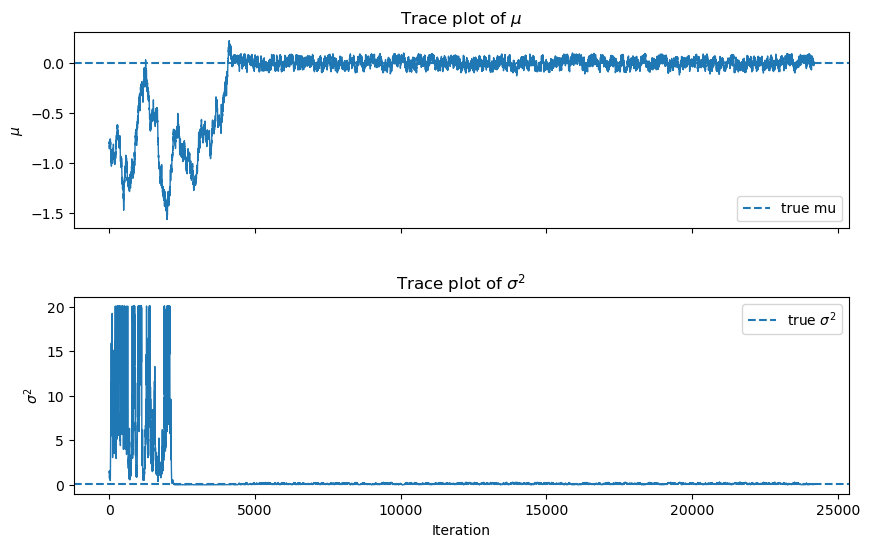

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(mcmc_chain["iter"], mcmc_chain["mu"], linewidth=1)
axes[0].axhline(mu_true, linestyle="--", label="true mu")
axes[0].set_ylabel(r"$\mu$")
axes[0].set_title(r"Trace plot of $\mu$")
axes[0].legend()

axes[1].plot(mcmc_chain["iter"], mcmc_chain["sigma2"], linewidth=1)
axes[1].axhline(sigma2_true, linestyle="--", label=r"true $\sigma^2$")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel(r"$\sigma^2$")
axes[1].set_title(r"Trace plot of $\sigma^2$")
axes[1].legend()

fig.subplots_adjust(hspace=0.35)
plt.show()

The trace plots below display the whole run, including both the initialization phase and the MCMC phase.

For $\mu$, the first part of the trajectory starts far from the true value and then progressively moves toward a stable region around
$$
\mu_0 = 0.
$$
After this initial transition, the chain fluctuates around the true value without showing a clear drift.

For $\sigma^2$, the beginning of the run shows very large values and strong variability. This corresponds to the initialization phase, during which the algorithm starts from a deliberately distant parameter and searches for a first ABC-compatible state. After this transition, the chain remains in a much smaller region close to
$$
\sigma_0^2 = 0.09.
$$

Overall, these plots show the expected behavior of the algorithm: starting from a poor initial value, entering the ABC-compatible region, and then exploring a more stable part of the parameter space. The early iterations should therefore be interpreted as a transient phase rather than as part of the posterior sample.

Because the initialization phase contains very large values of $\sigma^2$, the scale of the second plot is dominated by these early iterations. As a result, the fluctuations of the stabilized MCMC phase are visually compressed.

<div style="color:yellow; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Burn-in choice
</div>
From the trace plots, the chain appears to enter a stable regime after the first few thousand iterations.  
To be conservative, we discard the first 5000 iterations and plot the remaining sample.
We will also use the remaining sample for posterior summaries.

<div style="color:yellow; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Post-burn-in trace plots
</div>

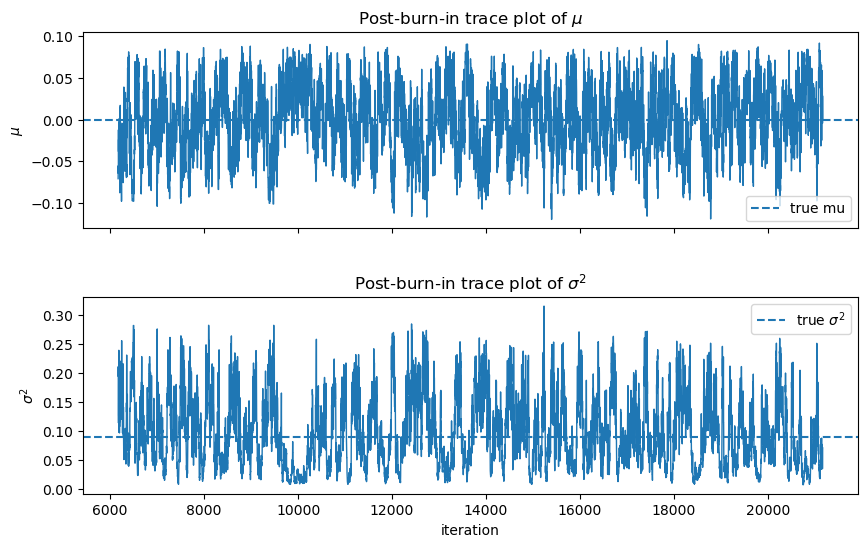

In [144]:
mcmc_only = mcmc_chain[mcmc_chain["phase"] == "mcmc"].copy().reset_index(drop=True)
burnin_idx = 5000

post_chain = mcmc_only.iloc[burnin_idx:].copy()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(post_chain["iter"], post_chain["mu"], linewidth=1)
axes[0].axhline(mu_true, linestyle="--", label="true mu")
axes[0].set_ylabel(r"$\mu$")
axes[0].set_title(r"Post-burn-in trace plot of $\mu$")
axes[0].legend()

axes[1].plot(post_chain["iter"], post_chain["sigma2"], linewidth=1)
axes[1].axhline(sigma2_true, linestyle="--", label=r"true $\sigma^2$")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel(r"$\sigma^2$")
axes[1].set_title(r"Post-burn-in trace plot of $\sigma^2$")
axes[1].legend()

fig.subplots_adjust(hspace=0.35)
plt.show()

The previous trace plots only display the post-burn-in part of the MCMC phase.

For $\mu$, the chain fluctuates around the true value
$$
\mu_0 = 0.
$$
There is no obvious long-term drift, which suggests that the chain explores a stable region of the posterior distribution.

For $\sigma^2$, the chain also fluctuates around the true value
$$
\sigma_0^2 = 0.09.
$$
The variability is larger than for $\mu$, and the trajectory is more irregular. This indicates that $\sigma^2$ is harder to estimate and mixes less smoothly than $\mu$. Still, the chain repeatedly returns to values close to the true parameter and remains in a plausible posterior region.

Overall, these post-burn-in trace plots suggest that the MCMC-ABC sampler is exploring the approximate posterior distribution in a reasonably stable way after the initial transient phase has been removed.

<div style="color:yellow; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Plots : Initial search, First MCMC moves (after initialisation), Cloud after burn-in
</div>

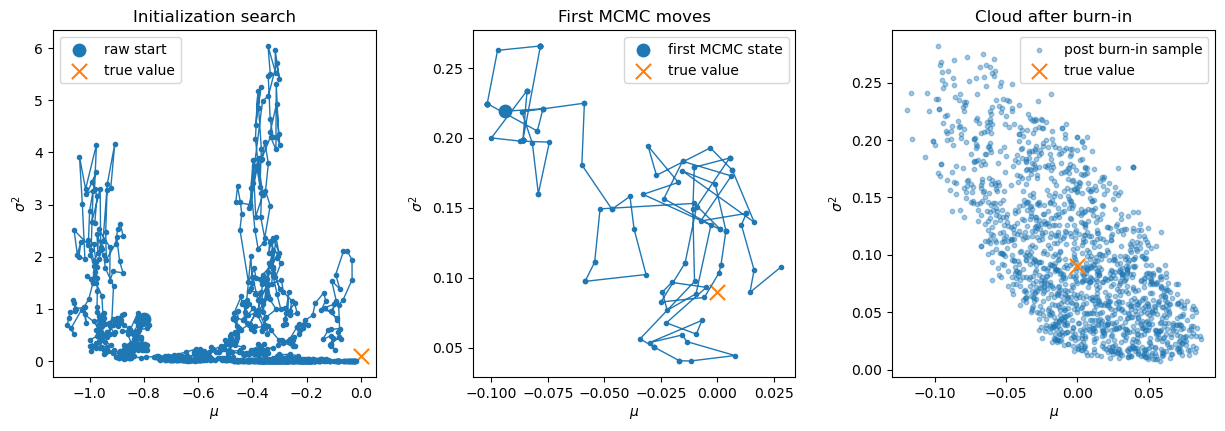

In [143]:
n_first = 120
thin = 10
burnin_idx = 5000
init_chain = mcmc_chain[mcmc_chain["phase"] == "initialization"].copy().reset_index(drop=True)
mcmc_only = mcmc_chain[mcmc_chain["phase"] == "mcmc"].copy().reset_index(drop=True)
mcmc_post = mcmc_only.iloc[burnin_idx:].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 1. Initialization search
axes[0].plot(
    init_chain["mu"],
    init_chain["sigma2"],
    marker="o",
    markersize=3,
    linewidth=1
)
axes[0].scatter(
    init_chain["mu"].iloc[0],
    init_chain["sigma2"].iloc[0],
    s=80,
    label="raw start"
)
axes[0].scatter(
    [mu_true],
    [sigma2_true],
    marker="x",
    s=120,
    label="true value"
)
axes[0].set_title("Initialization search")
axes[0].set_xlabel(r"$\mu$")
axes[0].set_ylabel(r"$\sigma^2$")
axes[0].legend()

# 2. First MCMC moves
n_first = 120
axes[1].plot(
    mcmc_only["mu"].iloc[:n_first],
    mcmc_only["sigma2"].iloc[:n_first],
    marker="o",
    markersize=3,
    linewidth=1
)
axes[1].scatter(
    mcmc_only["mu"].iloc[0],
    mcmc_only["sigma2"].iloc[0],
    s=80,
    label="first MCMC state"
)
axes[1].scatter(
    [mu_true],
    [sigma2_true],
    marker="x",
    s=120,
    label="true value"
)
axes[1].set_title("First MCMC moves")
axes[1].set_xlabel(r"$\mu$")
axes[1].set_ylabel(r"$\sigma^2$")
axes[1].legend()

# 3. Post-burn-in cloud
thin = 10
axes[2].scatter(
    mcmc_post["mu"].iloc[::thin],
    mcmc_post["sigma2"].iloc[::thin],
    s=10,
    alpha=0.4,
    label="post burn-in sample"
)
axes[2].scatter(
    [mu_true],
    [sigma2_true],
    marker="x",
    s=120,
    label="true value"
)
axes[2].set_title("Cloud after burn-in")
axes[2].set_xlabel(r"$\mu$")
axes[2].set_ylabel(r"$\sigma^2$")
axes[2].legend()

fig.subplots_adjust(wspace=0.3)
plt.show()

The three panels below summarize the successive stages of the MCMC-ABC procedure in the
$$
(\mu,\sigma^2)
$$
plane.

In the left panel, we show the initialization search starting from a deliberately poor initial value.  
The purpose of this phase is not to sample from the posterior distribution, but simply to find a first parameter value satisfying the ABC condition. This explains the irregular path and the large temporary values of $\sigma^2$.

 The algorithm explores widely at first, then eventually reaches the ABC-compatible region.

In the middle panel, we show the first iterations of the actual MCMC phase.  
Once a valid starting point has been found, the chain begins to move locally inside the ABC-compatible region. The trajectory is now much more concentrated than during initialization, which indicates that the sampler is no longer searching globally but rather exploring a plausible posterior region.

In the right panel, we display the post-burn-in sample.  
The cloud has a clear elongated shape, revealing a negative dependence between $\mu$ and $\sigma^2$.

This means that different combinations of these two parameters can produce simulated datasets with similar overall behavior. In particular, smaller values of $\mu$ can be compensated by larger values of $\sigma^2$ and conversely.

The true parameter lies inside the post-burn-in cloud, which is consistent with the fact that the MCMC-ABC algorithm is targeting a reasonable approximation of the ABC posterior distribution.

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Comparison with Reject-ABC
</div>

We now compare MCMC-ABC with Reject-ABC under the same ABC specification: the same prior, the same tolerance parameter $\varepsilon$, and the same discrepancy measure.

Both methods target the same ABC posterior distribution
$$
\pi_\varepsilon(\theta \mid y).
$$

The difference is therefore not the target distribution itself, but the way in which the parameter space is explored.

Reject-ABC draws parameters independently from the prior and accepts only those for which the simulated dataset is close enough to the observed data. By contrast, MCMC-ABC uses local proposals around the current state of the chain. Once the chain has entered a plausible region of the parameter space, it keeps exploring this region by local moves.

We first compare the posterior samples produced by the two methods for the same value of $\varepsilon$. We then compare their computational behavior for different values of $\varepsilon$ and for different choices of the prior.

In [145]:
# Keep only the MCMC phase, then remove burn-in
mcmc_only = mcmc_chain[mcmc_chain["phase"] == "mcmc"].copy().reset_index(drop=True)
post_chain = mcmc_only.iloc[burnin_idx:].copy()

# To make the scatter plots readable, we compare the same number of points
n_compare = min(len(abc_samples), len(post_chain))

reject_compare = abc_samples.iloc[:n_compare].copy()

idx = np.linspace(0, len(post_chain) - 1, n_compare).astype(int)
mcmc_compare = post_chain.iloc[idx].copy()

print("Reject-ABC sample size:", len(abc_samples))
print("MCMC post-burn-in sample size:", len(post_chain))
print("Number of points used for visual comparison:", n_compare)

Reject-ABC sample size: 200
MCMC post-burn-in sample size: 15000
Number of points used for visual comparison: 200


<div style="color:yellow; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Posterior summaries
</div>
If both algorithms are targeting the same ABC posterior, their posterior summaries should be similar. In particular, we compare the posterior means, medians, and standard deviations of $\mu$ and $\sigma^2$.

In [146]:
summary_table = pd.DataFrame({
    "quantity": ["mean(mu)", "median(mu)", "std(mu)",
                 "mean(sigma2)", "median(sigma2)", "std(sigma2)"],
    "Reject-ABC": [
        abc_samples["mu"].mean(),
        abc_samples["mu"].median(),
        abc_samples["mu"].std(),
        abc_samples["sigma2"].mean(),
        abc_samples["sigma2"].median(),
        abc_samples["sigma2"].std()
    ],
    "MCMC-ABC": [
        post_chain["mu"].mean(),
        post_chain["mu"].median(),
        post_chain["mu"].std(),
        post_chain["sigma2"].mean(),
        post_chain["sigma2"].median(),
        post_chain["sigma2"].std()
    ]
})

summary_table

,quantity,Reject-ABC,MCMC-ABC
0,mean(mu),-0.006184,-0.000520
1,median(mu),-0.004562,0.000749
2,std(mu),0.044882,0.042775
3,mean(sigma2),0.109738,0.099590
4,median(sigma2),0.099618,0.087510
5,std(sigma2),0.069013,0.062008


The posterior summaries produced by Reject-ABC and MCMC-ABC are quite close.

For $\mu$, the two methods give almost identical conclusions: the posterior means and medians are both very close to zero, and the posterior standard deviations are also very similar. This strongly supports the claim that both algorithms are targeting the same ABC posterior distribution.

For $\sigma^2$, the two methods again lead to similar conclusions, although the MCMC-ABC sample is slightly shifted toward smaller values. In particular, the MCMC-ABC posterior mean and median of $\sigma^2$ are both somewhat lower than the corresponding Reject-ABC values. However, the overall scale remains comparable, and both methods place substantial posterior mass near the true value
$$
\sigma_0^2 = 0.09.
$$

Overall, the summary table suggests that the two methods produce consistent posterior inference under the same ABC specification.

<div style="color:yellow; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Marginal posterior distributions
</div>
We now compare the marginal posterior distributions of $\mu$ and $\sigma^2$ obtained by Reject-ABC and by MCMC-ABC.

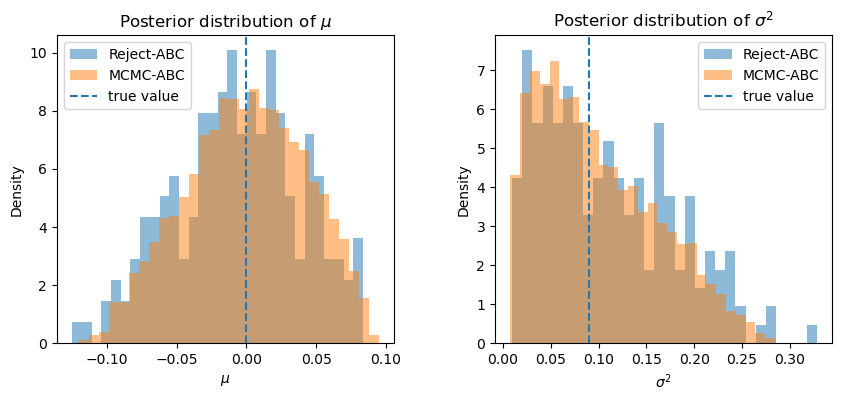

In [147]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# mu
axes[0].hist(abc_samples["mu"], bins=30, density=True, alpha=0.5, label="Reject-ABC")
axes[0].hist(post_chain["mu"], bins=30, density=True, alpha=0.5, label="MCMC-ABC")
axes[0].axvline(mu_true, linestyle="--", label="true value")
axes[0].set_xlabel(r"$\mu$")
axes[0].set_ylabel("Density")
axes[0].set_title(r"Posterior distribution of $\mu$")
axes[0].legend()

# sigma^2
axes[1].hist(abc_samples["sigma2"], bins=30, density=True, alpha=0.5, label="Reject-ABC")
axes[1].hist(post_chain["sigma2"], bins=30, density=True, alpha=0.5, label="MCMC-ABC")
axes[1].axvline(sigma2_true, linestyle="--", label="true value")
axes[1].set_xlabel(r"$\sigma^2$")
axes[1].set_ylabel("Density")
axes[1].set_title(r"Posterior distribution of $\sigma^2$")
axes[1].legend()

fig.subplots_adjust(wspace=0.3)
plt.show()

The marginal posterior histograms confirm the conclusions of the summary table.

For $\mu$, the two distributions almost overlap. Both are centered near the true value
$$
\mu_0 = 0,
$$
and both have a similar spread. This indicates that Reject-ABC and MCMC-ABC recover essentially the same marginal posterior information for $\mu$.

For $\sigma^2$, the two histograms also have a similar global shape. Both are right-skewed and assign most posterior mass to values below about $0.2$. The MCMC-ABC histogram appears slightly more concentrated on smaller values of $\sigma^2$, while the Reject-ABC histogram has a somewhat heavier upper tail. This difference is visible but remains moderate.

These histograms therefore support the idea that the two methods target the same ABC posterior, up to ordinary Monte Carlo variation.

<div style="color:yellow; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Posterior cloud in the parameter space
</div>
We also compare the two posterior samples in the $(\mu,\sigma^2)$ plane.

The Reject-ABC sample contains 200 accepted draws, whereas the MCMC-ABC post-burn-in sample contains 15000 draws. Since the two samples do not have the same size, we use only 200 points from each method in the visual comparison plots.

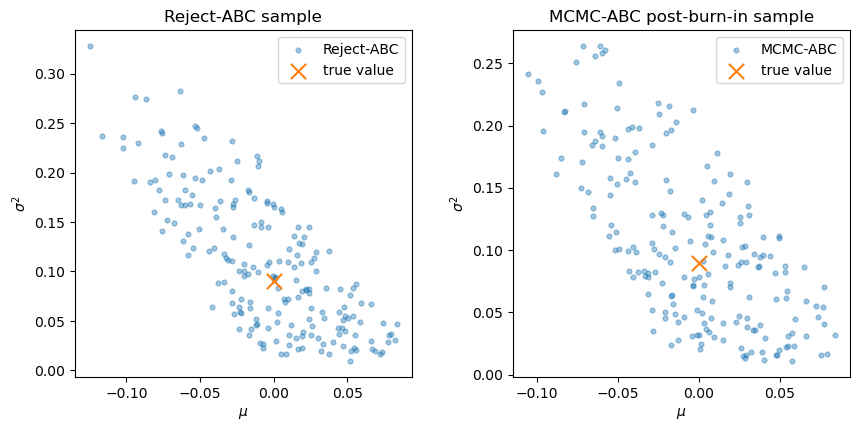

In [148]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].scatter(
    reject_compare["mu"],
    reject_compare["sigma2"],
    s=12,
    alpha=0.4,
    label="Reject-ABC"
)
axes[0].scatter(
    [mu_true],
    [sigma2_true],
    marker="x",
    s=120,
    label="true value"
)
axes[0].set_xlabel(r"$\mu$")
axes[0].set_ylabel(r"$\sigma^2$")
axes[0].set_title("Reject-ABC sample")
axes[0].legend()

axes[1].scatter(
    mcmc_compare["mu"],
    mcmc_compare["sigma2"],
    s=12,
    alpha=0.4,
    label="MCMC-ABC"
)
axes[1].scatter(
    [mu_true],
    [sigma2_true],
    marker="x",
    s=120,
    label="true value"
)
axes[1].set_xlabel(r"$\mu$")
axes[1].set_ylabel(r"$\sigma^2$")
axes[1].set_title("MCMC-ABC post-burn-in sample")
axes[1].legend()

fig.subplots_adjust(wspace=0.3)
plt.show()

The scatter plots in the $(\mu,\sigma^2)$ plane show that the two methods produce posterior clouds with the same global structure.

In both cases, the posterior sample has an elongated shape with a clear negative dependence between $\mu$ and $\sigma^2$. 

The true parameter lies inside both clouds, which is consistent with the fact that both methods are targeting the same ABC posterior distribution.

Although the two clouds are not identical point by point, their location, orientation, and overall spread are very similar. This is exactly what we expect when comparing independent Reject-ABC draws with correlated MCMC-ABC draws from the same target distribution.

<div style="color:yellow; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Interpretation of the comparison
</div>

If the two methods are correctly implemented, they should lead to similar posterior conclusions for the same ABC specification. Therefore, we do not expect the two samples to be identical, but we do expect them to have a similar location, a similar spread, and a similar global shape in the
$$
(\mu,\sigma^2)
$$
plane.

The main difference between the two methods should appear in computational efficiency rather than in the location of the posterior itself.

<div style="color:yellow; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Efficiency comparison
</div>
We now compare the computational behavior of the two methods.

Reject-ABC produces independent accepted draws, but it may waste many simulations because each proposal is drawn independently from the prior.

MCMC-ABC produces correlated draws, but once it has entered the relevant part of the parameter space, it keeps exploring this region by local moves.

A simple way to compare the two methods is to examine:

- the number of simulations,
- the acceptance rate,
- and the number of useful posterior draws produced under the same setting.

In [149]:
# Replace N_reject by the actual number of prior simulations used in Reject-ABC
N_reject = N

efficiency_table = pd.DataFrame({
    "method": ["Reject-ABC", "MCMC-ABC"],
    "number_of_simulations": [N_reject, len(mcmc_chain)],
    "accepted_or_kept_draws": [len(abc_samples), len(post_chain)],
    "acceptance_rate": [
        len(abc_samples) / N_reject,
        mcmc_acceptance_rate
    ]
})

efficiency_table

,method,number_of_simulations,accepted_or_kept_draws,acceptance_rate
0,Reject-ABC,20000,200,0.0100
1,MCMC-ABC,21168,15000,0.7303


The efficiency table shows a major computational difference between the two methods.

Reject-ABC uses 20000 simulations and accepts only 200 parameter values, corresponding to an acceptance rate of about
$$
0.01.
$$

By contrast, MCMC-ABC uses a comparable number of simulations and produces a long post-burn-in chain of 15000 draws, with an acceptance rate around
$$
0.73.
$$

This does not mean that MCMC-ABC produces 15000 independent posterior draws, since the MCMC sample is correlated. Nevertheless, it clearly shows that once the chain has entered the relevant part of the parameter space, it can keep generating useful posterior values much more efficiently than Reject-ABC, which repeatedly proposes irrelevant values from the prior.

Therefore, in this experiment, MCMC-ABC performs better in a computational sense, even though both methods target the same ABC posterior.

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Comparison for different values of $\varepsilon$ and different priors
</div>

To make this point more concrete, we now repeat the comparison under a few alternative settings.

For simplicity, we compare:

1. the current value of $\varepsilon$

2. a smaller value of $\varepsilon$

3. the current prior
4. a more diffuse prior

In [150]:
def compare_one_setting(epsilon_value, s_value, t_value,
                        N_reject, K_mcmc, burnin_value,
                        theta0, tau_mu, tau_eta, rng):
    # Reject-ABC
    all_results_tmp, abc_samples_tmp, epsilon_tmp = reject_abc(
        y_obs=y_obs,
        L=L,
        N=N_reject,
        s=s_value,
        t=t_value,
        epsilon=epsilon_value,
        q=None,
        rng=rng
    )

    # MCMC-ABC
    mcmc_chain_tmp, mcmc_acceptance_rate_tmp = mcmc_abc(
        y_obs=y_obs,
        L=L,
        K=K_mcmc,
        s=s_value,
        t=t_value,
        epsilon=epsilon_value,
        tau_mu=tau_mu,
        tau_eta=tau_eta,
        theta0=theta0
    )

    mcmc_only_tmp = mcmc_chain_tmp[mcmc_chain_tmp["phase"] == "mcmc"].copy().reset_index(drop=True)

    burnin_used = min(burnin_value, max(0, len(mcmc_only_tmp) - 1))
    post_tmp = mcmc_only_tmp.iloc[burnin_used:].copy()

    return {
        "epsilon": epsilon_value,
        "s": s_value,
        "t": t_value,
        "Reject-ABC accept rate": len(abc_samples_tmp) / N_reject,
        "MCMC-ABC accept rate": mcmc_acceptance_rate_tmp,
        "Reject-ABC mean mu": abc_samples_tmp["mu"].mean(),
        "MCMC-ABC mean mu": post_tmp["mu"].mean(),
        "Reject-ABC mean sigma2": abc_samples_tmp["sigma2"].mean(),
        "MCMC-ABC mean sigma2": post_tmp["sigma2"].mean(),
        "Reject-ABC draws": len(abc_samples_tmp),
        "MCMC-ABC post-burn-in draws": len(post_tmp)
    }

<div style="color:yellow; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Effect of a smaller value of epsilon
</div>

In [151]:
rng_compare = np.random.default_rng(2025)

epsilon_small = 0.7 * epsilon_used

compare_epsilon = pd.DataFrame([
    compare_one_setting(
        epsilon_value=epsilon_used,
        s_value=s,
        t_value=t,
        N_reject=10000,
        K_mcmc=20000,
        burnin_value=5000,
        theta0=theta_start_far,
        tau_mu=tau_mu,
        tau_eta=tau_eta,
        rng=rng_compare
    ),
    compare_one_setting(
        epsilon_value=epsilon_small,
        s_value=s,
        t_value=t,
        N_reject=10000,
        K_mcmc=20000,
        burnin_value=5000,
        theta0=theta_start_far,
        tau_mu=tau_mu,
        tau_eta=tau_eta,
        rng=rng_compare
    )
])

compare_epsilon

,epsilon,s,t,Reject-ABC accept rate,MCMC-ABC accept rate,Reject-ABC mean mu,MCMC-ABC mean mu,Reject-ABC mean sigma2,MCMC-ABC mean sigma2,Reject-ABC draws,MCMC-ABC post-burn-in draws
0,0.595467,1.0,2.0,0.0093,0.73125,-0.005005,-0.006420,0.095541,0.110045,93,15000
1,0.416827,1.0,2.0,0.0043,0.64520,-0.004980,-0.001079,0.106557,0.098538,43,15000


The comparison for two values of $\varepsilon$ illustrates the main advantage of MCMC-ABC.

When $\varepsilon$ is reduced from about
$$
0.595
$$
to about
$$
0.417,
$$
the Reject-ABC acceptance rate drops from about
$$
0.0093
$$
to
$$
0.0043.
$$
This means that the number of accepted Reject-ABC draws is approximately divided by two, decreasing from 93 to 43 for the same simulation budget.

By contrast, the MCMC-ABC acceptance rate also decreases, but much less dramatically: it goes from about
$$
0.73
$$
to about
$$
0.65.
$$
The posterior means remain close across the two methods, but the computational cost of Reject-ABC becomes much more severe when $\varepsilon$ is small.

This is exactly the situation in which MCMC-ABC is expected to be advantageous: when the ABC acceptance region is small, independent prior sampling becomes very inefficient, whereas local proposals can still explore the relevant region of the parameter space.

<div style="color:yellow; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Effect of a more diffuse prior
</div>

In [152]:
rng_compare = np.random.default_rng(2026)

s_wide = 2 * s
t_wide = 2 * t

compare_prior = pd.DataFrame([
    compare_one_setting(
        epsilon_value=epsilon_used,
        s_value=s,
        t_value=t,
        N_reject=10000,
        K_mcmc=20000,
        burnin_value=5000,
        theta0=theta_start_far,
        tau_mu=tau_mu,
        tau_eta=tau_eta,
        rng=rng_compare
    ),
    compare_one_setting(
        epsilon_value=epsilon_used,
        s_value=s_wide,
        t_value=t_wide,
        N_reject=10000,
        K_mcmc=20000,
        burnin_value=5000,
        theta0=theta_start_far,
        tau_mu=tau_mu,
        tau_eta=tau_eta,
        rng=rng_compare
    )
])

compare_prior

/var/folders/45/48t8s0w969gbt8ry74nlqvcw0000gn/T/ipykernel_97526/1809667945.py:4: RuntimeWarning: overflow encountered in exp
  Y = np.exp(X).sum(axis=1)


,epsilon,s,t,Reject-ABC accept rate,MCMC-ABC accept rate,Reject-ABC mean mu,MCMC-ABC mean mu,Reject-ABC mean sigma2,MCMC-ABC mean sigma2,Reject-ABC draws,MCMC-ABC post-burn-in draws
0,0.595467,1.0,2.0,0.0129,0.7278,-0.008683,-0.005528,0.115146,0.107651,129,15000
1,0.595467,2.0,4.0,0.0041,0.7699,0.003297,0.005996,0.079913,0.083605,41,15000


The prior comparison leads to a similar conclusion.

When the prior is made more diffuse by increasing
$$
s
$$
and
$$
t,
$$
the Reject-ABC acceptance rate drops sharply, from about
$$
0.0129
$$
to
$$
0.0041.
$$
The number of accepted Reject-ABC draws also falls substantially, from 129 to 41.

This happens because a diffuse prior places much more mass on irrelevant regions of the parameter space, so many independent prior draws produce simulated datasets that are far from the observation.

By contrast, the MCMC-ABC acceptance rate remains high, around
$$
0.73 \text{ to } 0.77.
$$
This is because, after initialization, the chain no longer samples globally from the prior, but instead explores locally around already plausible parameter values.

Therefore, the advantage of MCMC-ABC becomes more pronounced when the prior is diffuse. This is exactly the theoretical behavior expected from the algorithm.

Overall, the numerical comparison confirms the theoretical discussion.

First, Reject-ABC and MCMC-ABC lead to very similar posterior conclusions when they are run under the same ABC specification. This supports the claim that both methods target the same ABC posterior distribution.

Second, MCMC-ABC performs better in a computational sense. Its advantage becomes especially visible when the tolerance parameter $\varepsilon$ is small and when the prior is diffuse. In both situations, Reject-ABC wastes many simulations in irrelevant parts of the parameter space, whereas MCMC-ABC is able to keep exploring the relevant region by local moves.

Therefore, the numerical experiments support the idea that MCMC-ABC may be preferable when independent prior sampling becomes too inefficient.